In [ ]:
%pip install XGboost
%pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 55.6 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:

import os
import gc
import time
import random
import warnings

import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib

In [ ]:
# Defile File Path

CALENDAR_PATH = "calendar.csv"
SALES_PATH = "sales_train_evaluation.csv"
PRICES_PATH = "sell_prices.csv"

## Loading Calender table

In [ ]:
# Load Calender Table

calendar_df = pd.read_csv(CALENDAR_PATH)
print("Calendar dataset loaded successfully.\n")
print("Rows:", f"{calendar_df.shape[0]:,}")
print("Columns:", calendar_df.shape[1])
print("\n")
print(calendar_df.info())
display(calendar_df.head())

Calendar dataset loaded successfully.

Rows: 1,969
Columns: 14


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB
None


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


# Convert Date column into Datetime formate
# Also check Invalid Dates

In [ ]:
# Convert the date column to datetime format

calendar_df["date"] = pd.to_datetime(
    calendar_df["date"],
    errors="coerce"
)

# Check for invalid dates
invalid_dates = calendar_df["date"].isna().sum()

print("Invalid dates:", invalid_dates)

print("\nCalendar date range:")
print("Start:", calendar_df["date"].min())
print("End:", calendar_df["date"].max())

Invalid dates: 0

Calendar date range:
Start: 2011-01-29 00:00:00
End: 2016-06-19 00:00:00


## selecte 183 days Sales Table

In [ ]:
# Load Sales Table first select daily sales columns

sales_columns = pd.read_csv(SALES_PATH, nrows=0).columns.tolist()

daily_columns = [
    column for column in sales_columns
    if column.startswith("d_")
]
print("Total daily sales columns:", len(daily_columns))
print("First daily column:", daily_columns[0])
print("Last daily column:", daily_columns[-1])

Total daily sales columns: 1941
First daily column: d_1
Last daily column: d_1941


In [ ]:
# Select last 6 Month Data from Calender

N_DAYS = 183

selected_days = daily_columns[-N_DAYS:]

START_DAY = selected_days[0]
END_DAY = selected_days[-1]

ID_COLUMNS = [ "id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
required_sales_columns = ID_COLUMNS + selected_days

print("Number of selected days:", len(selected_days))
print("Starting sales column:", START_DAY)
print("Ending sales column:", END_DAY)
print("\nBasic columns of sales table :", len(ID_COLUMNS))
print("Selected daily columns:", len(selected_days))
print("Total columns to load:", len(required_sales_columns))

Number of selected days: 183
Starting sales column: d_1759
Ending sales column: d_1941

Basic columns of sales table : 6
Selected daily columns: 183
Total columns to load: 189


# Final Selected Start and End Date for Training and Testing

In [ ]:
selected_calendar = calendar_df[
    calendar_df["d"].isin(selected_days)
].copy()
start_date = selected_calendar["date"].min()
end_date = selected_calendar["date"].max()
print("Selected Data Start and End Date for Model Training and Testing")
print("Start date:", start_date.strftime("%d %B %Y"))
print("End date:", end_date.strftime("%d %B %Y"))

Selected Data Start and End Date for Model Training and Testing
Start date: 22 November 2015
End date: 22 May 2016


# Load Sales Data

In [ ]:
# Load the sales data with only the required columns

print("Only the selected 183-day period will be loaded.")

sales_df = pd.read_csv(
    SALES_PATH,
    usecols=required_sales_columns,
    low_memory=False
)
print("\n")
print(sales_df.columns)
print("\nRows:", f"{sales_df.shape[0]:,}")
print("Columns:", sales_df.shape[1])
display(sales_df.head())

Only the selected 183-day period will be loaded.


Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1759',
       'd_1760', 'd_1761', 'd_1762',
       ...
       'd_1932', 'd_1933', 'd_1934', 'd_1935', 'd_1936', 'd_1937', 'd_1938',
       'd_1939', 'd_1940', 'd_1941'],
      dtype='object', length=189)

Rows: 30,490
Columns: 189


,id,item_id,dept_id,cat_id,store_id,state_id,d_1759,d_1760,d_1761,d_1762,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,3,0,1,3,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,1,3,3,3,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,2,1,2,0,...,0,0,0,2,1,0,0,2,1,0


In [ ]:
sales_missing = sales_df.isna().sum()

sales_missing = sales_missing[
    sales_missing > 0
].sort_values(
    ascending=False
)

if sales_missing.empty:
    print("No missing values found in the selected sales dataset.")
else:
    print("Columns containing missing values:")
    display(sales_missing.to_frame("Missing Values"))

No missing values found in the selected sales dataset.


## Load Price Table

In [ ]:
# Load Price Table

sell_prices_df = pd.read_csv(
    PRICES_PATH,
    low_memory=False
)
print("\nPrice dataset loaded successfully.")
print("\nRows:", f"{sell_prices_df.shape[0]:,}")
print("Columns:", sell_prices_df.shape[1])

print("\nPrice Table Columns : ",sell_prices_df.columns)

display(sell_prices_df.head())


Price dataset loaded successfully.

Rows: 6,841,121
Columns: 4

Price Table Columns :  Index(['store_id', 'item_id', 'wm_yr_wk', 'sell_price'], dtype='object')


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [ ]:
# Check missing values and invalid prices

price_missing = sell_prices_df.isna().sum()

print("Missing values in selling price data:")
display(price_missing.to_frame("Missing Values"))

negative_prices = (
    sell_prices_df["sell_price"] < 0
).sum()

zero_prices = (
    sell_prices_df["sell_price"] == 0
).sum()

print("\nPrice validation:")
print("Negative prices:", negative_prices)
print("Zero prices:", zero_prices)

Missing values in selling price data:


,Missing Values
store_id,0
item_id,0
wm_yr_wk,0
sell_price,0



Price validation:
Negative prices: 0
Zero prices: 0


## Wide to Long Format

In [ ]:
# Before melt sales data prepared for convert columns into rows
sales_df = sales_df.copy()
sales_df[selected_days] = sales_df[selected_days].astype("int32")
print("Sales data prepared for wide-to-long transformation.")
print("Current shape:", sales_df.shape)

Sales data prepared for wide-to-long transformation.
Current shape: (30490, 189)


In [ ]:
# simply convert daily columns convert into rows


sales_long_df = sales_df.melt(
    id_vars=ID_COLUMNS,
    value_vars=selected_days,
    var_name="d",
    value_name="sales"
)
print("Rows:", f"{sales_long_df.shape[0]:,}")
print("Columns:", sales_long_df.shape[1])

display(sales_long_df.head())

Rows: 5,579,670
Columns: 8


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1759,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1759,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1759,3
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1759,1
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1759,2


## Replace empty events features by *none*

In [ ]:
# select column for day of last 183 days
calendar_selected_df = calendar_df[
    calendar_df["d"].isin(selected_days)
].copy()
calendar_columns = calendar_selected_df.columns.tolist()
calendar_selected_df = calendar_selected_df[calendar_columns].copy()

In [ ]:
# Replace empty values
event_columns = [
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2"
]

calendar_selected_df[event_columns] = (
    calendar_selected_df[event_columns]
    .fillna("None")
)

# Merge Sales and calender df

In [ ]:
# Merge Sales and calender table
sales_calendar_df = sales_long_df.merge(
    calendar_selected_df,
    on="d",
    how="left",
    validate="many_to_one"
)
print("Sales-calendar merge completed.")
print("Rows:", f"{sales_calendar_df.shape[0]:,}")
print("Columns:", sales_calendar_df.shape[1])
print("\n")
print(sales_calendar_df.columns)
print("\n")
display(sales_calendar_df.head())


Sales-calendar merge completed.
Rows: 5,579,670
Columns: 21


Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI'],
      dtype='object')




,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1759,1,2015-11-22,11543,...,2,11,2015,None,None,None,None,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1759,0,2015-11-22,11543,...,2,11,2015,None,None,None,None,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1759,3,2015-11-22,11543,...,2,11,2015,None,None,None,None,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1759,1,2015-11-22,11543,...,2,11,2015,None,None,None,None,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1759,2,2015-11-22,11543,...,2,11,2015,None,None,None,None,0,0,0


In [ ]:
# check missing values in sales and callender table

calendar_features = calendar_selected_df.columns.tolist()
calendar_merge_missing = (
    sales_calendar_df[calendar_features]
    .isna()
    .sum()
)

print("Missing values after sales-calendar merge:")

display(
    calendar_merge_missing[
        calendar_merge_missing > 0
    ].to_frame("Missing Values")
)


Missing values after sales-calendar merge:


,Missing Values


There is NO Missing Values are in dataset till now

## Prepare Price

In [ ]:
# check price data
required_weeks = (
    sales_calendar_df["wm_yr_wk"]
    .dropna()
    .unique()
)
sell_prices_selected_df = sell_prices_df[
    sell_prices_df["wm_yr_wk"].isin(required_weeks)
].copy()

print("Original price rows:", f"{len(sell_prices_df):,}")
print(
    "Price rows for selected period:",
    f"{len(sell_prices_selected_df):,}"
)

Original price rows: 6,841,121
Price rows for selected period: 823,016


In [ ]:
# Identify the  weeks required for the 183-day study period

required_weeks = (
    sales_calendar_df["wm_yr_wk"]
    .dropna()
    .unique()
)

print("Number of  weeks required:", len(required_weeks))
print("First few weeks:", required_weeks[:10])

Number of  weeks required: 27
First few weeks: [11543 11544 11545 11546 11547 11548 11549 11550 11551 11552]


In [ ]:
# Keep only prices corresponding to the selected study period

sell_prices_selected_df = sell_prices_df[
    sell_prices_df["wm_yr_wk"].isin(required_weeks)
].copy()

print("Original price rows:", f"{len(sell_prices_df):,}")
print(
    "Price rows for selected period:",
    f"{len(sell_prices_selected_df):,}"
)

print(
    "Reduction in price rows:",
    f"{(1 - len(sell_prices_selected_df) / len(sell_prices_df)) * 100:.2f}%"
)

Original price rows: 6,841,121
Price rows for selected period: 823,016
Reduction in price rows: 87.97%


In [ ]:
price_key = [
    "store_id",
    "item_id",
    "wm_yr_wk"
]

duplicate_price_keys = (
    sell_prices_selected_df
    .duplicated(subset=price_key)
    .sum()
)

print(
    "Duplicate store-item-week price records:",
    duplicate_price_keys
)


print("Price merge key is unique.")

Duplicate store-item-week price records: 0
Price merge key is unique.


There are No Duplicate Recodes are found

In [ ]:
key_cols = ["store_id", "item_id", "wm_yr_wk"]

duplicates = (
    sell_prices_selected_df
    .groupby(key_cols)
    .size()
    .reset_index(name="count")
    .query("count > 1")
    .sort_values("count", ascending=False)
)

display(duplicates.head(20))
print("Number of duplicate key combinations:", len(duplicates))

,store_id,item_id,wm_yr_wk,count


Number of duplicate key combinations: 0


# Final Merge with price Table

In [ ]:
# sales, calendar table merge with price Table

model_data = sales_calendar_df.merge(
    sell_prices_selected_df,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left",
    validate="many_to_one"
)
print("Sales, calendar, and price merge completed.")
print("Rows:", f"{model_data.shape[0]:,}")
print("Columns:", model_data.shape[1])
print("\n")
print(model_data.columns)
print("\n")
display(model_data.head())

Sales, calendar, and price merge completed.
Rows: 5,579,670
Columns: 22


Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'sell_price'],
      dtype='object')




,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1759,1,2015-11-22,11543,...,11,2015,None,None,None,None,0,0,0,8.26
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1759,0,2015-11-22,11543,...,11,2015,None,None,None,None,0,0,0,3.97
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1759,3,2015-11-22,11543,...,11,2015,None,None,None,None,0,0,0,2.97
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1759,1,2015-11-22,11543,...,11,2015,None,None,None,None,0,0,0,4.64
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1759,2,2015-11-22,11543,...,11,2015,None,None,None,None,0,0,0,2.88


In [ ]:
print("Final dataset structure:")
final_structure_summary = pd.DataFrame({
    "Variable": [
        "Product IDs",
        "Departments",
        "Categories",
        "Stores",
        "States",
        "Product-Store Series"
    ],
    "Unique Values": [
        model_data["item_id"].nunique(),
        model_data["dept_id"].nunique(),
        model_data["cat_id"].nunique(),
        model_data["store_id"].nunique(),
        model_data["state_id"].nunique(),
        model_data["id"].nunique()
    ]
})
display(final_structure_summary)

Final dataset structure:


,Variable,Unique Values
0,Product IDs,3049
1,Departments,7
2,Categories,3
3,Stores,10
4,States,3
5,Product-Store Series,30490


In [ ]:
print("Dataset date range:")
print("Start:", model_data["date"].min())
print("End:", model_data["date"].max())

unique_dates = model_data["date"].nunique()

print("Unique dates:", unique_dates)



Dataset date range:
Start: 2015-11-22 00:00:00
End: 2016-05-22 00:00:00
Unique dates: 183


In [ ]:
OUTPUT_PATH = "m5_183_day_integrated.csv"
model_data.to_csv(
    OUTPUT_PATH,
    index=False
)


In [ ]:
model_data.to_parquet(
    "m5_183_day_integrated.parquet",
    index=False
)

print("Parquet dataset saved successfully.")

Parquet dataset saved successfully.


# Shape of Final Dataset

In [ ]:
print("Final dataset shape:", model_data.shape)

Final dataset shape: (5579670, 22)


# check Missing Values in Final Dataset

In [ ]:
model_merge_missing = (
    model_data[model_data.columns.tolist()]
    .isna()
    .sum()
)

print("Missing values after sales-calendar merge:")

display(
    model_merge_missing[
        model_merge_missing > 0
    ].to_frame("Missing Values")
)


Missing values after sales-calendar merge:


,Missing Values
sell_price,1470


In [ ]:
# Check missing selling prices after the merge

missing_prices = model_data["sell_price"].isna().sum()

missing_price_percentage = (
    missing_prices / len(model_data)
) * 100

print("Missing selling prices:", f"{missing_prices:,}")
print(
    "Missing price percentage:",
    f"{missing_price_percentage:.2f}%"
)

Missing selling prices: 1,470
Missing price percentage: 0.03%


# Exploratory Data Analysis

In [ ]:
eda_df = model_data

print("EDA dataset shape:", eda_df.shape)

EDA dataset shape: (5579670, 22)


In [ ]:
# how many unique products are in each department

print("Unique products in particular dept.")
display(eda_df.groupby('dept_id')['item_id'].nunique())

Unique products in particular dept.


,item_id
dept_id,
FOODS_1,216
FOODS_2,398
FOODS_3,823
HOBBIES_1,416
HOBBIES_2,149
HOUSEHOLD_1,532
HOUSEHOLD_2,515


state_id
CA    3150956
WI    2279147
TX    1988177
Name: sales, dtype: int32


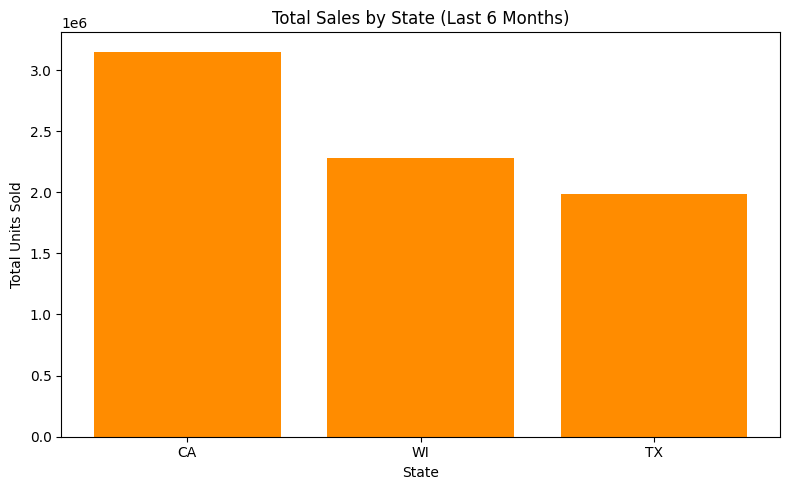

In [ ]:
# show total sales by state

sales_by_state = eda_df.groupby("state_id")["sales"].sum().sort_values(ascending=False)
print(sales_by_state)

plt.figure(figsize=(8, 5))
plt.bar(sales_by_state.index, sales_by_state.values, color="darkorange")
plt.title("Total Sales by State (Last 6 Months)")
plt.xlabel("State")
plt.ylabel("Total Units Sold")
plt.tight_layout()
plt.show()

store_id
CA_3    1117294
WI_2     898249
CA_1     801005
CA_2     773634
TX_2     719272
WI_3     694969
TX_3     686805
WI_1     685929
TX_1     582100
CA_4     459023
Name: sales, dtype: int32


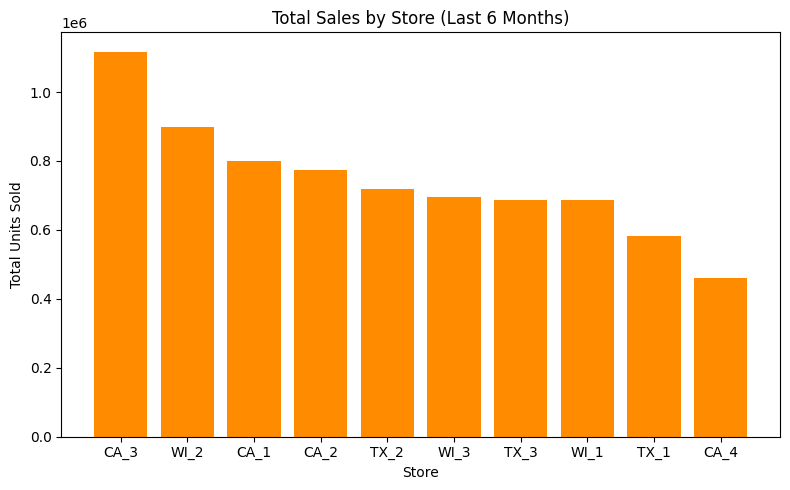

In [ ]:
# show total sales by store
sales_by_state = eda_df.groupby("store_id")["sales"].sum().sort_values(ascending=False)
print(sales_by_state)

plt.figure(figsize=(8, 5))
plt.bar(sales_by_state.index, sales_by_state.values, color="darkorange")
plt.title("Total Sales by Store (Last 6 Months)")
plt.xlabel("Store")
plt.ylabel("Total Units Sold")
plt.tight_layout()
plt.show()

cat_id
FOODS        4926325
HOUSEHOLD    1774302
HOBBIES       717653
Name: sales, dtype: int32


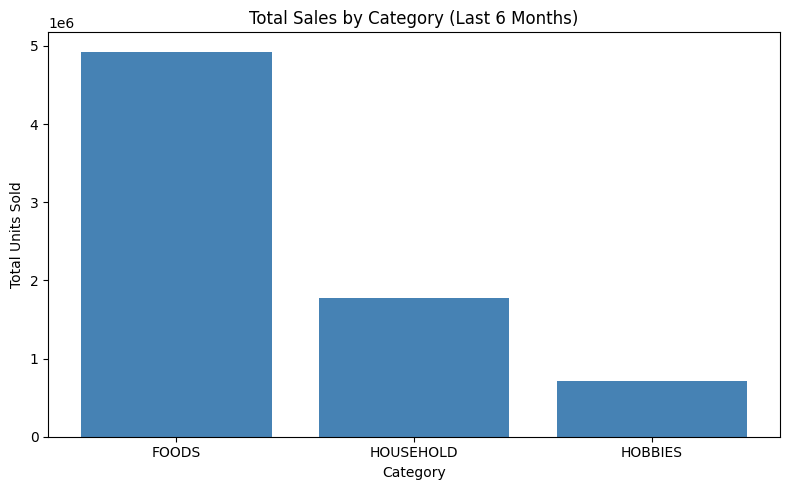

In [ ]:
# show total sales by categories

sales_by_cat = eda_df.groupby("cat_id")["sales"].sum().sort_values(ascending=False)
print(sales_by_cat)

plt.figure(figsize=(8, 5))
plt.bar(sales_by_cat.index, sales_by_cat.values, color="steelblue")
plt.title("Total Sales by Category (Last 6 Months)")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")
plt.tight_layout()
plt.show()

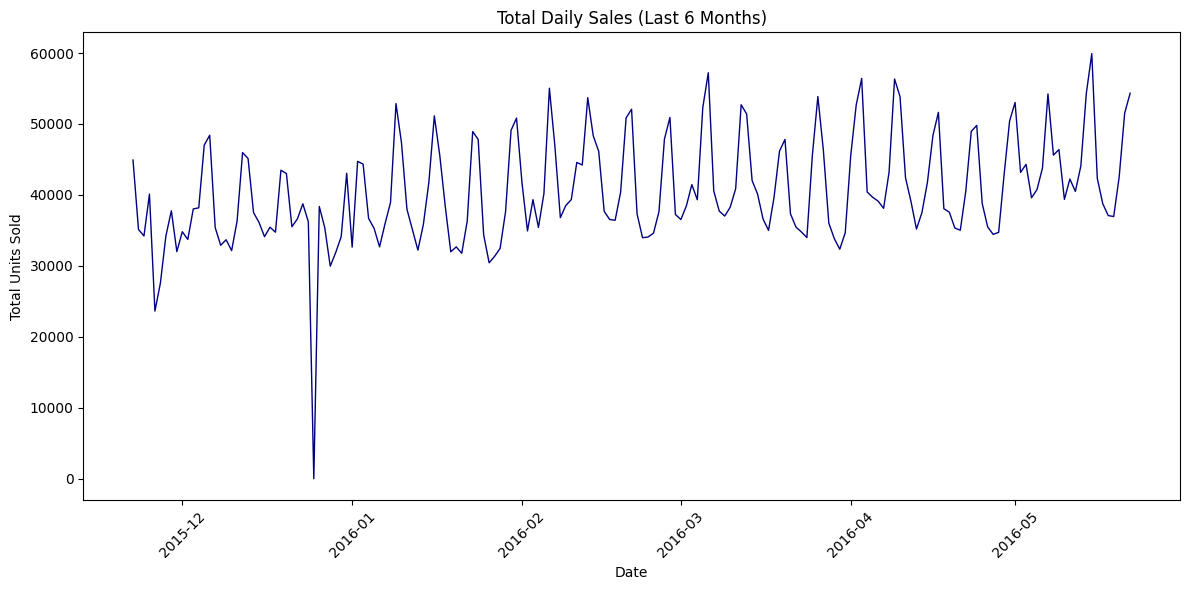

In [ ]:
# Monthly total sales

daily_sales = eda_df.groupby("date")["sales"].sum()

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.values, linewidth=1, color="navy")
plt.title("Total Daily Sales (Last 6 Months)")
plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

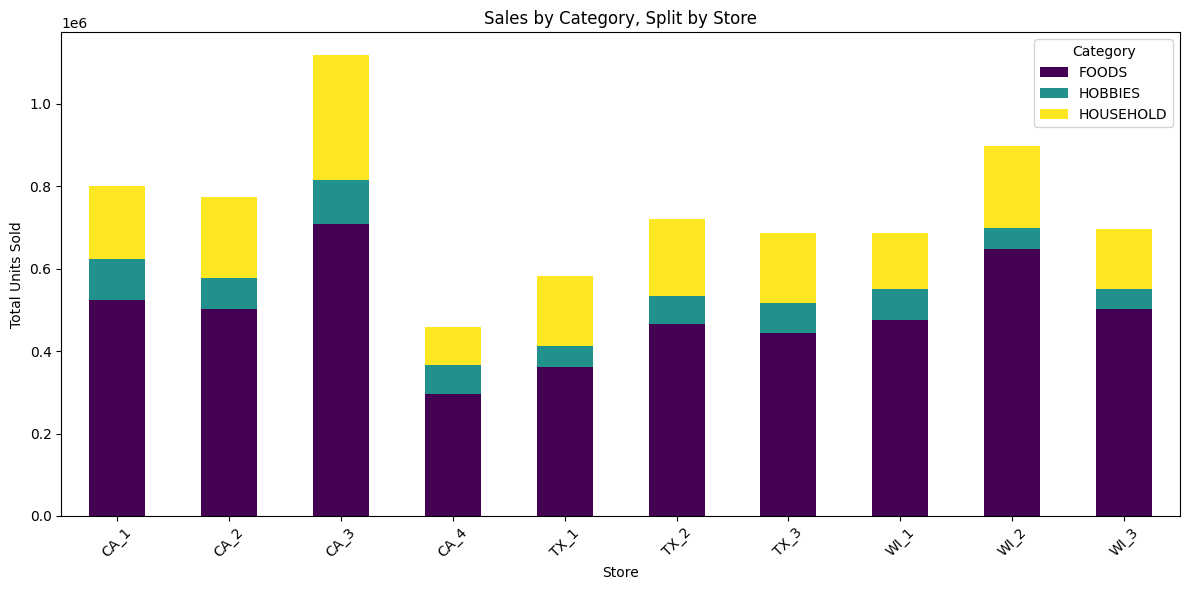

In [ ]:
# Sales by category in each store

cat_store_sales = eda_df.groupby(["store_id", "cat_id"])["sales"].sum().unstack()

cat_store_sales.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")
plt.title("Sales by Category, Split by Store")
plt.xlabel("Store")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.tight_layout()
plt.show()

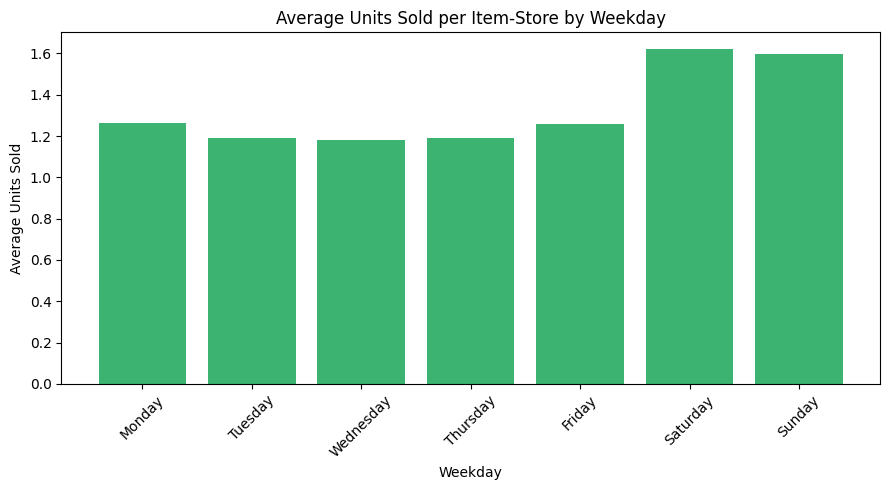

In [ ]:
# Totall sales according to Weekdays

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_sales = eda_df.groupby("weekday")["sales"].mean().reindex(weekday_order)

plt.figure(figsize=(9, 5))
plt.bar(weekday_sales.index, weekday_sales.values, color="mediumseagreen")
plt.title("Average Units Sold per Item-Store by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

    Non-SNAP Day  SNAP Day
CA      1.391610  1.453196
TX      1.154833  1.255231
WI      1.276757  1.535462


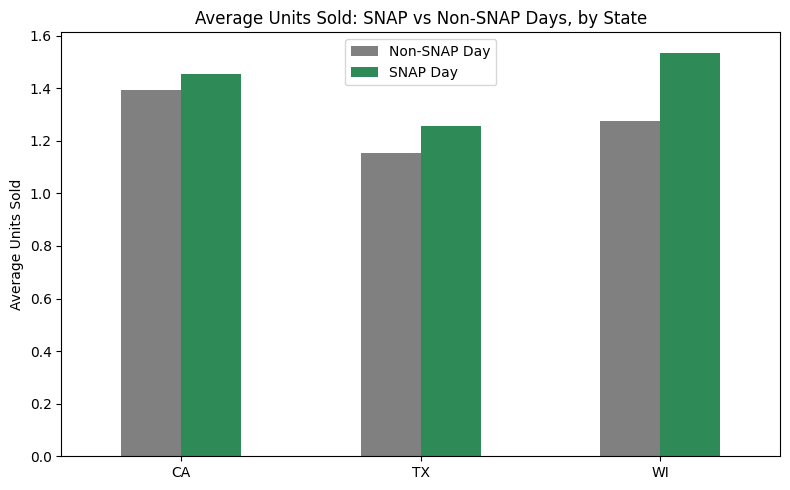

In [ ]:
# SNAP DAY sales and NON SNAP DAY sales

snap_col = {"CA": "snap_CA", "TX": "snap_TX", "WI": "snap_WI"}

snap_effect = {}
for state, col in snap_col.items():
    state_df = eda_df[eda_df["state_id"] == state]
    snap_effect[state] = state_df.groupby(col)["sales"].mean()

snap_effect_df = pd.DataFrame(snap_effect).T
snap_effect_df.columns = ["Non-SNAP Day", "SNAP Day"]
print(snap_effect_df)

snap_effect_df.plot(kind="bar", figsize=(8, 5), color=["gray", "seagreen"])
plt.title("Average Units Sold: SNAP vs Non-SNAP Days, by State")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

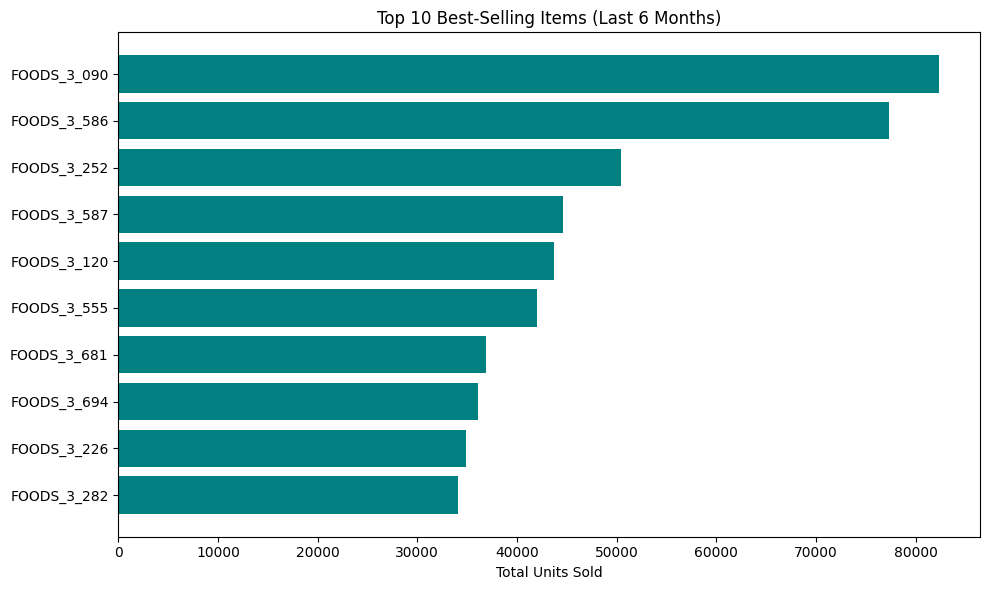

In [ ]:
# Top 10 Best selling products

top_items = eda_df.groupby("item_id")["sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_items.index[::-1], top_items.values[::-1], color="teal")
plt.title("Top 10 Best-Selling Items (Last 6 Months)")
plt.xlabel("Total Units Sold")
plt.tight_layout()
plt.show()

In [ ]:
# Event Summary

event_summary = (
    calendar_selected_df
    .groupby("event_type_1")
    .size()
    .reset_index(name="days")
    .sort_values("days", ascending=False)
)

display(event_summary)

,event_type_1,days
2,None,165
3,Religious,7
0,Cultural,5
1,National,5
4,Sporting,1


# Handle Missing Values

In [ ]:
# check Missing values in Table

missing_rows = model_data[model_data.isna().any(axis=1)].copy()

missing_columns_by_row = (missing_rows.isna().sum(axis=1))

print("Missing columns per affected row:")

display(
    missing_rows.isna()
    .sum()
    .to_frame("Missing Values")
)

Missing columns per affected row:


,Missing Values
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
sales,0
date,0
wm_yr_wk,0


In [ ]:
# Check all missing values before treatment

missing_before = (
    model_data.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_before = missing_before[
    missing_before > 0
]

print("Missing values before treatment:")

display(
    missing_before.to_frame("Missing Values")
)

Missing values before treatment:


,Missing Values
sell_price,1470


In [ ]:
# Remove missing value recode
rows_before = len(model_data)

model_data_clean = (
    model_data
    .dropna(
        subset=["sell_price"]
    )
    .copy()
    .reset_index(drop=True)
)

rows_after = len(model_data_clean)

rows_removed = rows_before - rows_after

print("Missing-price treatment")
print("----------------------")
print("Rows before cleaning:", f"{rows_before:,}")
print("Rows removed:", f"{rows_removed:,}")
print("Rows after cleaning:", f"{rows_after:,}")

Missing-price treatment
----------------------
Rows before cleaning: 5,579,670
Rows removed: 1,470
Rows after cleaning: 5,578,200


In [ ]:
# Check for remaining missing values after cleaning

remaining_missing = (
    model_data_clean
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

remaining_missing = remaining_missing[
    remaining_missing > 0
]

if remaining_missing.empty:
    print("No missing values remain in the dataset.")

No missing values remain in the dataset.


# duplicate Values check

In [ ]:
print("Number of duplicate rows:", model_data_clean.duplicated().sum())


Number of duplicate rows: 0


There are No Missing values and Duplicate recodes in out dataset

# Feature Engineering

In [ ]:
feature_df = model_data_clean.copy()

print("Feature engineering dataset shape:")
print(feature_df.shape)

Feature engineering dataset shape:
(5578200, 22)


In [ ]:
# Sort all data according to date

feature_df.sort_values(
    by=["id", "date"],
    inplace=True,
    ignore_index=True
)

print("Data sorted successfully.")

display(
    feature_df[
        ["id", "date", "sales"]
    ].head(10)
)

Data sorted successfully.


,id,date,sales
0,FOODS_1_001_CA_1_evaluation,2015-11-22,1
1,FOODS_1_001_CA_1_evaluation,2015-11-23,1
2,FOODS_1_001_CA_1_evaluation,2015-11-24,1
3,FOODS_1_001_CA_1_evaluation,2015-11-25,0
4,FOODS_1_001_CA_1_evaluation,2015-11-26,2
5,FOODS_1_001_CA_1_evaluation,2015-11-27,1
6,FOODS_1_001_CA_1_evaluation,2015-11-28,0
7,FOODS_1_001_CA_1_evaluation,2015-11-29,1
8,FOODS_1_001_CA_1_evaluation,2015-11-30,0
9,FOODS_1_001_CA_1_evaluation,2015-12-01,0


# create Temporal variable

In [ ]:
# Temporal variable are created, which help us for better calculation

feature_df["day_of_week"] = (
    feature_df["date"].dt.dayofweek
)

feature_df["day_of_month"] = (
    feature_df["date"].dt.day
)

feature_df["week_of_year"] = (
    feature_df["date"]
    .dt.isocalendar()
    .week
    .astype("int16")
)

feature_df["month_num"] = (
    feature_df["date"].dt.month
)

feature_df["year_num"] = (
    feature_df["date"].dt.year
)

print("Temporal features created.")

display(
    feature_df[
        [
            "date",
            "day_of_week",
            "day_of_month",
            "week_of_year",
            "month_num",
            "year_num"
        ]
    ].head()
)

Temporal features created.


,date,day_of_week,day_of_month,week_of_year,month_num,year_num
0,2015-11-22,6,22,47,11,2015
1,2015-11-23,0,23,48,11,2015
2,2015-11-24,1,24,48,11,2015
3,2015-11-25,2,25,48,11,2015
4,2015-11-26,3,26,48,11,2015


# create weekend Indicator

In [ ]:
feature_df["is_weekend"] = (
    feature_df["day_of_week"] >= 5
).astype("int8")

print("Weekend indicator created.")

display(
    feature_df[
        [
            "date",
            "day_of_week",
            "is_weekend"
        ]
    ].head(10)
)

Weekend indicator created.


,date,day_of_week,is_weekend
0,2015-11-22,6,1
1,2015-11-23,0,0
2,2015-11-24,1,0
3,2015-11-25,2,0
4,2015-11-26,3,0
5,2015-11-27,4,0
6,2015-11-28,5,1
7,2015-11-29,6,1
8,2015-11-30,0,0
9,2015-12-01,1,0


# Create Primary Event Indicator

In [ ]:
feature_df["has_event"] = (
    feature_df["event_type_1"] != "None"
).astype("int8")

print("Primary event indicator created.")

print(
    "Event observations:",
    f"{feature_df['has_event'].sum():,}"
)

print(
    "Non-event observations:",
    f"{(feature_df['has_event'] == 0).sum():,}"
)

Primary event indicator created.
Event observations: 548,683
Non-event observations: 5,029,517


# Create Secondary Event Indicator

In [ ]:
feature_df["has_event_2"] = (
    feature_df["event_type_2"] != "None"
).astype("int8")

print("Secondary event indicator created.")

print(
    "Secondary event observations:",
    f"{feature_df['has_event_2'].sum():,}"
)

Secondary event indicator created.
Secondary event observations: 0


# Encode dummy Event Types

In [ ]:
event_dummies = pd.get_dummies(
    feature_df[
        [
            "event_type_1",
            "event_type_2"
        ]
    ],
    prefix=[
        "event_type_1",
        "event_type_2"
    ],
    dtype="int8"
)

feature_df = pd.concat(
    [
        feature_df,
        event_dummies
    ],
    axis=1
)

print("Event type encoding completed.")
print(
    "Number of event dummy variables:",
    event_dummies.shape[1]
)

Event type encoding completed.
Number of event dummy variables: 6


# SNAP Indicator

In [ ]:
feature_df["snap_active"] = (
    feature_df[
        [
            "snap_CA",
            "snap_TX",
            "snap_WI"
        ]
    ].max(axis=1)
).astype("int8")

print("SNAP indicator created.")

display(
    feature_df[[ "date", "snap_CA", "snap_TX", "snap_WI", "snap_active"]].head()
)

SNAP indicator created.


,date,snap_CA,snap_TX,snap_WI,snap_active
0,2015-11-22,0,0,0,0
1,2015-11-23,0,0,0,0
2,2015-11-24,0,0,0,0
3,2015-11-25,0,0,0,0
4,2015-11-26,0,0,0,0


# Lag Feature
### sales value of exact value of sales * days ago (1day ago, 7 day ago, etc.)

In [ ]:

lag_periods = [1, 7, 14, 28]

for lag in lag_periods:
    feature_df[f"lag_{lag}"] = (
        feature_df
        .groupby("id")["sales"]
        .shift(lag)
    )

print("Lag features created.")

display(
    feature_df[
        [
            "id",
            "date",
            "sales",
            "lag_1",
            "lag_7",
            "lag_14",
            "lag_28"
        ]
    ].head(30)
)

Lag features created.


,id,date,sales,lag_1,lag_7,lag_14,lag_28
0,FOODS_1_001_CA_1_evaluation,2015-11-22,1,NaN,NaN,NaN,NaN
1,FOODS_1_001_CA_1_evaluation,2015-11-23,1,1.0,NaN,NaN,NaN
2,FOODS_1_001_CA_1_evaluation,2015-11-24,1,1.0,NaN,NaN,NaN
3,FOODS_1_001_CA_1_evaluation,2015-11-25,0,1.0,NaN,NaN,NaN
4,FOODS_1_001_CA_1_evaluation,2015-11-26,2,0.0,NaN,NaN,NaN
5,FOODS_1_001_CA_1_evaluation,2015-11-27,1,2.0,NaN,NaN,NaN
6,FOODS_1_001_CA_1_evaluation,2015-11-28,0,1.0,NaN,NaN,NaN
7,FOODS_1_001_CA_1_evaluation,2015-11-29,1,0.0,1.0,NaN,NaN
8,FOODS_1_001_CA_1_evaluation,2015-11-30,0,1.0,1.0,NaN,NaN
9,FOODS_1_001_CA_1_evaluation,2015-12-01,0,0.0,1.0,NaN,NaN


# create 7 Days Rolling Average

In [ ]:
feature_df["rolling_mean_7"] = (
    feature_df
    .groupby("id")["sales"]
    .transform(
        lambda x: (
            x.shift(1)
            .rolling(
                window=7,
                min_periods=7
            )
            .mean()
        )
    )
)

print("Seven-day rolling mean created.")

Seven-day rolling mean created.


# create 14 Days Rolling Average

In [ ]:
feature_df["rolling_mean_14"] = (
    feature_df
    .groupby("id")["sales"]
    .transform(
        lambda x: (
            x.shift(1)
            .rolling(
                window=14,
                min_periods=14
            )
            .mean()
        )
    )
)

print("Fourteen-day rolling mean created.")

Fourteen-day rolling mean created.


# create 28 Days Rolling Average

In [ ]:

feature_df["rolling_mean_28"] = (
    feature_df
    .groupby("id")["sales"]
    .transform(
        lambda x: (
            x.shift(1)
            .rolling(
                window=28,
                min_periods=28
            )
            .mean()
        )
    )
)

print("Twenty-eight-day rolling mean created.")

Twenty-eight-day rolling mean created.


# 7 Day Rolling Standard Deviation

In [ ]:
feature_df["rolling_std_7"] = (
    feature_df
    .groupby("id")["sales"]
    .transform(
        lambda x: (
            x.shift(1)
            .rolling(
                window=7,
                min_periods=7
            )
            .std()
        )
    )
)

print("Seven-day rolling standard deviation created.")

Seven-day rolling standard deviation created.


# 28 Day Rolling Standard Deviation

In [ ]:

feature_df["rolling_std_28"] = (
    feature_df
    .groupby("id")["sales"]
    .transform(
        lambda x: (
            x.shift(1)
            .rolling(
                window=28,
                min_periods=28
            )
            .std()
        )
    )
)

print("Twenty-eight-day rolling standard deviation created.")

Twenty-eight-day rolling standard deviation created.


# Create Previous Price

In [ ]:
feature_df["previous_price"] = (
    feature_df
    .groupby("id")["sell_price"]
    .shift(1)
)

print("Previous price feature created.")

display(
    feature_df[
        [
            "id",
            "date",
            "sell_price",
            "previous_price"
        ]
    ].head(10)
)

Previous price feature created.


,id,date,sell_price,previous_price
0,FOODS_1_001_CA_1_evaluation,2015-11-22,2.24,NaN
1,FOODS_1_001_CA_1_evaluation,2015-11-23,2.24,2.24
2,FOODS_1_001_CA_1_evaluation,2015-11-24,2.24,2.24
3,FOODS_1_001_CA_1_evaluation,2015-11-25,2.24,2.24
4,FOODS_1_001_CA_1_evaluation,2015-11-26,2.24,2.24
5,FOODS_1_001_CA_1_evaluation,2015-11-27,2.24,2.24
6,FOODS_1_001_CA_1_evaluation,2015-11-28,2.24,2.24
7,FOODS_1_001_CA_1_evaluation,2015-11-29,2.24,2.24
8,FOODS_1_001_CA_1_evaluation,2015-11-30,2.24,2.24
9,FOODS_1_001_CA_1_evaluation,2015-12-01,2.24,2.24


# Create Price Change

In [ ]:
feature_df["price_change"] = (
    feature_df["sell_price"] -
    feature_df["previous_price"]
)

print("Price change feature created.")

display(
    feature_df[
        [
            "date",
            "sell_price",
            "previous_price",
            "price_change"
        ]
    ].head(10)
)

Price change feature created.


,date,sell_price,previous_price,price_change
0,2015-11-22,2.24,NaN,NaN
1,2015-11-23,2.24,2.24,0.0
2,2015-11-24,2.24,2.24,0.0
3,2015-11-25,2.24,2.24,0.0
4,2015-11-26,2.24,2.24,0.0
5,2015-11-27,2.24,2.24,0.0
6,2015-11-28,2.24,2.24,0.0
7,2015-11-29,2.24,2.24,0.0
8,2015-11-30,2.24,2.24,0.0
9,2015-12-01,2.24,2.24,0.0


# Create Percentage Price Change

In [ ]:
feature_df["price_change_percentage"] = np.where(
    (
        feature_df["previous_price"].notna()
        &
        (feature_df["previous_price"] != 0)
    ),
    (
        (
            feature_df["sell_price"] -
            feature_df["previous_price"]
        )
        /
        feature_df["previous_price"]
    ) * 100,
    0
)

print("Percentage price change feature created.")

display(feature_df[[ "date", "sell_price", "previous_price", "price_change_percentage"]].head())

Percentage price change feature created.


,date,sell_price,previous_price,price_change_percentage
0,2015-11-22,2.24,NaN,0.0
1,2015-11-23,2.24,2.24,0.0
2,2015-11-24,2.24,2.24,0.0
3,2015-11-25,2.24,2.24,0.0
4,2015-11-26,2.24,2.24,0.0


In [ ]:
# Define the engineered forecasting features

engineered_features = [
    "day_of_week",
    "day_of_month",
    "week_of_year",
    "month_num",
    "year_num",
    "is_weekend",
    "has_event",
    "has_event_2",
    "snap_CA",
    "snap_TX",
    "snap_WI",
    "snap_active",
    "sell_price",
    "previous_price",
    "price_change",
    "price_change_percentage",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_28"
]
historical_features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_28"
]
print(
    "Number of engineered/core forecasting features:",
    len(engineered_features)
)

Number of engineered/core forecasting features: 25


In [ ]:
# removing missing values in historical features

feature_df = (
    feature_df
    .dropna(
        subset=historical_features
    )
    .reset_index(drop=True)
)


In [ ]:
rows_before_feature_cleaning = len(feature_df)

feature_df = (
    feature_df
    .dropna(
        subset=historical_features
    )
    .reset_index(drop=True)
)

In [ ]:
remaining_missing = (
    feature_df[
        engineered_features
    ]
    .isna()
    .sum()
)

remaining_missing = remaining_missing[
    remaining_missing > 0
]

if remaining_missing.empty:
    print(
        "No missing values remain in the selected modelling features."
    )
else:
    print("Remaining missing values:")
    display(
        remaining_missing.to_frame(
            "Missing Values"
        )
    )

No missing values remain in the selected modelling features.


In [ ]:
display(
    feature_df[
        [
            "id",
            "date",
            "sales",
            "sell_price",
            "day_of_week",
            "is_weekend",
            "has_event",
            "snap_active",
            "lag_1",
            "lag_7",
            "lag_14",
            "lag_28",
            "rolling_mean_7",
            "rolling_mean_14",
            "rolling_mean_28",
            "rolling_std_7",
            "rolling_std_28"
        ]
    ].head(20)
)

,id,date,sales,sell_price,day_of_week,is_weekend,has_event,snap_active,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,rolling_std_7,rolling_std_28
0,FOODS_1_001_CA_1_evaluation,2015-12-20,0,2.24,6,1,0,0,2.0,4.0,0.0,1.0,1.000000,1.142857,0.964286,1.527525,1.170063
1,FOODS_1_001_CA_1_evaluation,2015-12-21,0,2.24,0,0,0,0,0.0,0.0,2.0,1.0,0.428571,1.142857,0.928571,0.786796,1.184110
2,FOODS_1_001_CA_1_evaluation,2015-12-22,1,2.24,1,0,0,0,0.0,1.0,4.0,1.0,0.428571,1.000000,0.892857,0.786796,1.196887
3,FOODS_1_001_CA_1_evaluation,2015-12-23,2,2.24,2,0,0,0,1.0,0.0,1.0,0.0,0.428571,0.785714,0.892857,0.786796,1.196887
4,FOODS_1_001_CA_1_evaluation,2015-12-24,0,2.24,3,0,0,0,2.0,0.0,1.0,2.0,0.714286,0.857143,0.964286,0.951190,1.201300
5,FOODS_1_001_CA_1_evaluation,2015-12-25,0,2.24,4,0,1,0,0.0,0.0,1.0,1.0,0.714286,0.785714,0.892857,0.951190,1.196887
6,FOODS_1_001_CA_1_evaluation,2015-12-26,1,2.24,5,1,0,0,0.0,2.0,0.0,0.0,0.714286,0.714286,0.857143,0.951190,1.208436
7,FOODS_1_001_CA_1_evaluation,2015-12-27,0,2.24,6,1,0,0,1.0,0.0,4.0,1.0,0.571429,0.785714,0.892857,0.786796,1.196887
8,FOODS_1_001_CA_1_evaluation,2015-12-28,0,2.24,0,0,0,0,0.0,0.0,0.0,0.0,0.571429,0.500000,0.857143,0.786796,1.208436
9,FOODS_1_001_CA_1_evaluation,2015-12-29,0,2.24,1,0,0,0,0.0,1.0,1.0,0.0,0.571429,0.500000,0.857143,0.786796,1.208436


# Train Test Split Data Prep

In [ ]:
# define Target variable and predictor variab;e
feature_columns = [
    "day_of_week",
    "day_of_month",
    "week_of_year",
    "month_num",
    "year_num",
    "is_weekend",
    "has_event",
    "has_event_2",
    "snap_CA",
    "snap_TX",
    "snap_WI",
    "snap_active",
    "sell_price",
    "previous_price",
    "price_change",
    "price_change_percentage",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_28"
]

target_column = "sales"

print("Number of predictor variables:", len(feature_columns))
print("Target variable:", target_column)

Number of predictor variables: 25
Target variable: sales


In [ ]:
# Sort the dataset chronologically

feature_df = (
    feature_df
    .sort_values(["date", "id"])
    .reset_index(drop=True)
)

print(
    "Earliest modelling date:",
    feature_df["date"].min()
)

print(
    "Latest modelling date:",
    feature_df["date"].max()
)

Earliest modelling date: 2015-12-20 00:00:00
Latest modelling date: 2016-05-22 00:00:00


In [ ]:
# define training and testing dates
unique_dates = (
    feature_df["date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

split_index = int(len(unique_dates) * 0.80)

train_end_date = unique_dates.iloc[split_index - 1]
test_start_date = unique_dates.iloc[split_index]



print("Total modelling dates:", len(unique_dates))
print("Training dates:", split_index)
print("Testing dates:", len(unique_dates) - split_index)
print("\nTraining Start Date:",feature_df["date"].min())
print("Training end date:", train_end_date)
print("\nTesting start date:", test_start_date)
print("Testing End Date:",feature_df["date"].max())

Total modelling dates: 155
Training dates: 124
Testing dates: 31

Training Start Date: 2015-12-20 00:00:00
Training end date: 2016-04-21 00:00:00

Testing start date: 2016-04-22 00:00:00
Testing End Date: 2016-05-22 00:00:00


In [ ]:
# Create training and testing datasets

train_df = feature_df[
    feature_df["date"] <= train_end_date
].copy()

test_df = feature_df[
    feature_df["date"] >= test_start_date
].copy()

print("Training observations:", f"{len(train_df):,}")
print("Testing observations:", f"{len(test_df):,}")

Training observations: 3,779,290
Testing observations: 945,190


In [ ]:
# create training and testing dataset

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3779290, 25)
y_train shape: (3779290,)
X_test shape: (945190, 25)
y_test shape: (945190,)


In [ ]:
# Create item frequency encoding using training data only

item_frequency = (
    train_df["item_id"]
    .value_counts(normalize=True)
)

train_df["item_frequency"] = (
    train_df["item_id"]
    .map(item_frequency)
)

test_df["item_frequency"] = (
    test_df["item_id"]
    .map(item_frequency)
)

# Handle any unseen products in the test set
test_df["item_frequency"] = (
    test_df["item_frequency"]
    .fillna(0)
)

print("Item frequency encoding completed.")

Item frequency encoding completed.


In [ ]:
# One-hot encode department, category, store and state variables

one_hot_columns = [
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

train_encoded = pd.get_dummies(
    train_df[one_hot_columns],
    columns=one_hot_columns,
    dtype="int8"
)

test_encoded = pd.get_dummies(
    test_df[one_hot_columns],
    columns=one_hot_columns,
    dtype="int8"
)

# Ensure training and testing have identical columns
train_encoded, test_encoded = train_encoded.align(
    test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print("One-hot encoding completed.")
print("Encoded columns:", train_encoded.shape[1])

One-hot encoding completed.
Encoded columns: 23


In [ ]:
# Combine numerical forecasting features with encoded categorical features

numerical_features = feature_columns.copy()

X_train_numeric = train_df[
    numerical_features
].copy()

X_test_numeric = test_df[
    numerical_features
].copy()

# Add product frequency encoding
X_train_numeric["item_frequency"] = (
    train_df["item_frequency"]
)

X_test_numeric["item_frequency"] = (
    test_df["item_frequency"]
)

# Combine numerical and categorical features
X_train_final = pd.concat(
    [
        X_train_numeric.reset_index(drop=True),
        train_encoded.reset_index(drop=True)
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        X_test_numeric.reset_index(drop=True),
        test_encoded.reset_index(drop=True)
    ],
    axis=1
)

print("Final feature matrices created.")
print("X_train:", X_train_final.shape)
print("X_test :", X_test_final.shape)

Final feature matrices created.
X_train: (3779290, 49)
X_test : (945190, 49)


In [ ]:
# Define the final target variables

y_train_final = train_df[
    "sales"
].reset_index(drop=True)

y_test_final = test_df[
    "sales"
].reset_index(drop=True)

print("Target variables prepared.")
print("y_train:", y_train_final.shape)
print("y_test :", y_test_final.shape)

Target variables prepared.
y_train: (3779290,)
y_test : (945190,)


# Model 1 : Linear Reggresion

In [ ]:
# Prepare training and testing data for Linear Regression

X_train_lr = X_train_final.copy()
X_test_lr = X_test_final.copy()

y_train_lr = y_train_final.copy()
y_test_lr = y_test_final.copy()

print("Linear Regression data prepared.")
print("X_train:", X_train_lr.shape)
print("X_test :", X_test_lr.shape)
print("y_train:", y_train_lr.shape)
print("y_test :", y_test_lr.shape)

Linear Regression data prepared.
X_train: (3779290, 49)
X_test : (945190, 49)
y_train: (3779290,)
y_test : (945190,)


In [ ]:

# Scale Linear Regression features using training data only

scaler_lr = StandardScaler()

X_train_lr_scaled = scaler_lr.fit_transform(
    X_train_lr
)

X_test_lr_scaled = scaler_lr.transform(
    X_test_lr
)

print("Feature scaling completed.")
print("Training matrix:", X_train_lr_scaled.shape)
print("Testing matrix :", X_test_lr_scaled.shape)

Feature scaling completed.
Training matrix: (3779290, 49)
Testing matrix : (945190, 49)


In [ ]:
# Train the Linear Regression model

linear_regression_model = LinearRegression()

linear_regression_model.fit(X_train_lr_scaled,y_train_lr)

print("Linear Regression model trained")

Linear Regression model trained


In [ ]:
lr_predictions = (
    linear_regression_model.predict(
        X_test_lr_scaled
    )
)
print("Predictions generated")

Predictions generated


In [ ]:
# Ensure predicted sales cannot be negative

lr_predictions = np.maximum(
    lr_predictions,
    0
)

print("Negative predictions removed.")
print(
    "Minimum prediction:",
    lr_predictions.min()
)

Negative predictions removed.
Minimum prediction: 0.0


In [ ]:
# Define forecasting evaluation metrics

def calculate_forecasting_metrics(actual, predicted):
    """
    Calculate MAE, RMSE, R2 and MAPE for demand forecasting.
    """

    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    non_zero_mask = actual > 0

    if non_zero_mask.sum() > 0:
        mape = np.mean(
            np.abs(
                (
                    actual[non_zero_mask] -
                    predicted[non_zero_mask]
                )
                /
                actual[non_zero_mask]
            )
        ) * 100
    else:
        mape = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

In [ ]:
# Evaluate Linear Regression predictions

lr_metrics = calculate_forecasting_metrics(
    y_test_lr,
    lr_predictions
)

print("Linear Regression Performance")
print("------------------------------")
print(f"MAE  : {lr_metrics['MAE']:.4f}")
print(f"RMSE : {lr_metrics['RMSE']:.4f}")
print(f"R²   : {lr_metrics['R2']:.4f}")
print(f"MAPE : {lr_metrics['MAPE']:.2f}%")

Linear Regression Performance
------------------------------
MAE  : 1.0099
RMSE : 2.0152
R²   : 0.6957
MAPE : 58.10%


In [ ]:
# Create a sample of actual versus predicted sales

lr_comparison = pd.DataFrame({
    "Actual_Sales": y_test_lr.values,
    "Predicted_Sales": lr_predictions
})

display(
    lr_comparison.head(20)
)

,Actual_Sales,Predicted_Sales
0,1,0.688867
1,0,1.752712
2,0,0.663828
3,1,0.039535
4,0,0.142819
5,0,0.533598
6,0,0.779915
7,0,0.370313
8,0,0.332890
9,0,0.032374


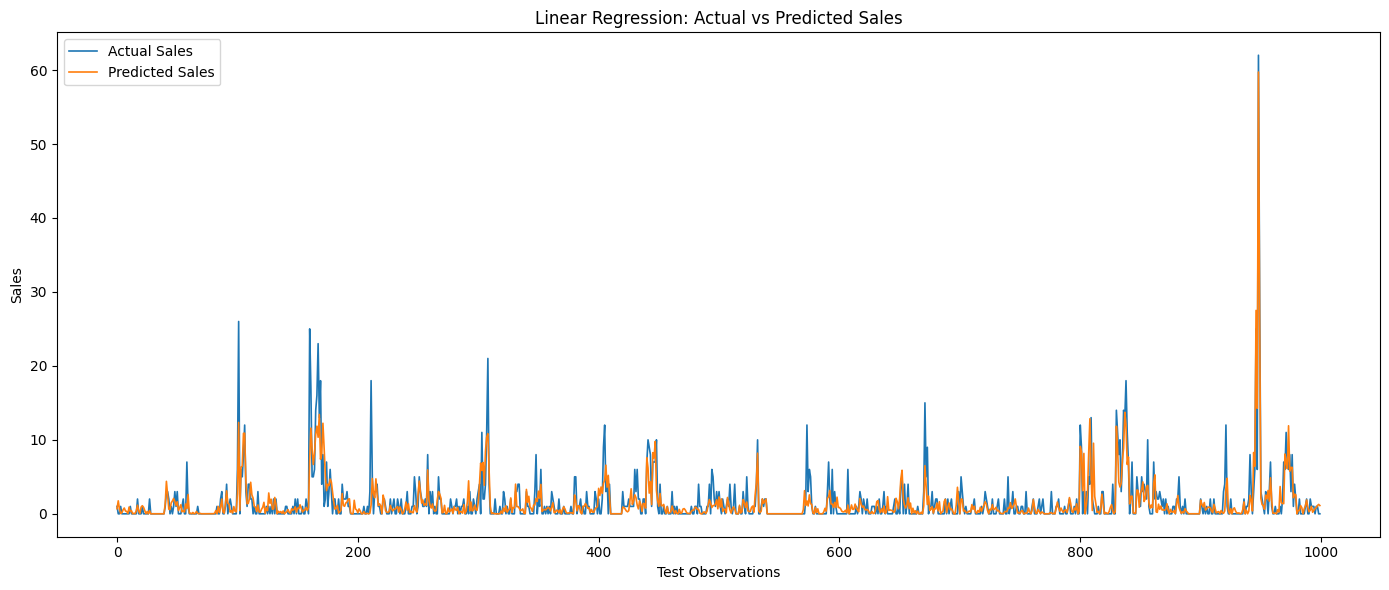

In [ ]:
# Plot actual versus predicted sales for a sample of test observations

plot_sample_size = min(
    1000,
    len(lr_comparison)
)

plot_data = (
    lr_comparison
    .iloc[:plot_sample_size]
    .copy()
)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["Actual_Sales"].values,
    label="Actual Sales",
    linewidth=1.2
)

plt.plot(
    plot_data["Predicted_Sales"].values,
    label="Predicted Sales",
    linewidth=1.2
)

plt.title(
    "Linear Regression: Actual vs Predicted Sales"
)

plt.xlabel("Test Observations")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save the trained Linear Regression model and scaler

joblib.dump(
    linear_regression_model,
    "linear_regression_model.pkl"
)

joblib.dump(
    scaler_lr,
    "linear_regression_scaler.pkl"
)

print("Linear Regression model saved successfully.")

Linear Regression model saved successfully.


# Model 2: Random Forest Regression

In [ ]:
# Prepare training and testing data for Random Forest

X_train_rf = X_train_final.copy()
X_test_rf = X_test_final.copy()

y_train_rf = y_train_final.copy()
y_test_rf = y_test_final.copy()

print("Random Forest data prepared.")
print("X_train:", X_train_rf.shape)
print("X_test :", X_test_rf.shape)

Random Forest data prepared.
X_train: (3779290, 49)
X_test : (945190, 49)


In [ ]:
# Define the Random Forest regression model

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

print("Random Forest model defined.")

Random Forest model defined.


In [ ]:
# Train the Random Forest model

random_forest_model.fit(
    X_train_rf,
    y_train_rf
)
print("Random Forest model trained")

Random Forest model trained


In [ ]:
# Generate Random Forest predictions

rf_predictions = (
    random_forest_model.predict(
        X_test_rf
    )
)

In [ ]:
# Ensure predicted demand cannot be negative

rf_predictions = np.maximum(
    rf_predictions,
    0
)

print(
    "Minimum Random Forest prediction:",
    rf_predictions.min()
)

Minimum Random Forest prediction: 0.012441059228042513


In [ ]:
# Evaluate Random Forest performance

rf_metrics = calculate_forecasting_metrics(
    y_test_rf,
    rf_predictions
)

print("Random Forest Performance")
print("-------------------------")
print(f"MAE  : {rf_metrics['MAE']:.4f}")
print(f"RMSE : {rf_metrics['RMSE']:.4f}")
print(f"R²   : {rf_metrics['R2']:.4f}")
print(f"MAPE : {rf_metrics['MAPE']:.2f}%")

Random Forest Performance
-------------------------
MAE  : 0.9986
RMSE : 1.9478
R²   : 0.7157
MAPE : 55.09%


In [ ]:
# Calculate Random Forest feature importance

rf_feature_importance = pd.DataFrame({
    "Feature": X_train_rf.columns,
    "Importance": random_forest_model.feature_importances_
})

rf_feature_importance = (
    rf_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_feature_importance.head(20)
)

,Feature,Importance
0,rolling_mean_14,0.160587
1,rolling_mean_7,0.160181
2,rolling_mean_28,0.154897
3,lag_1,0.121401
4,lag_7,0.085708
5,rolling_std_28,0.075019
6,rolling_std_7,0.054554
7,lag_28,0.052001
8,lag_14,0.042950
9,sell_price,0.014061


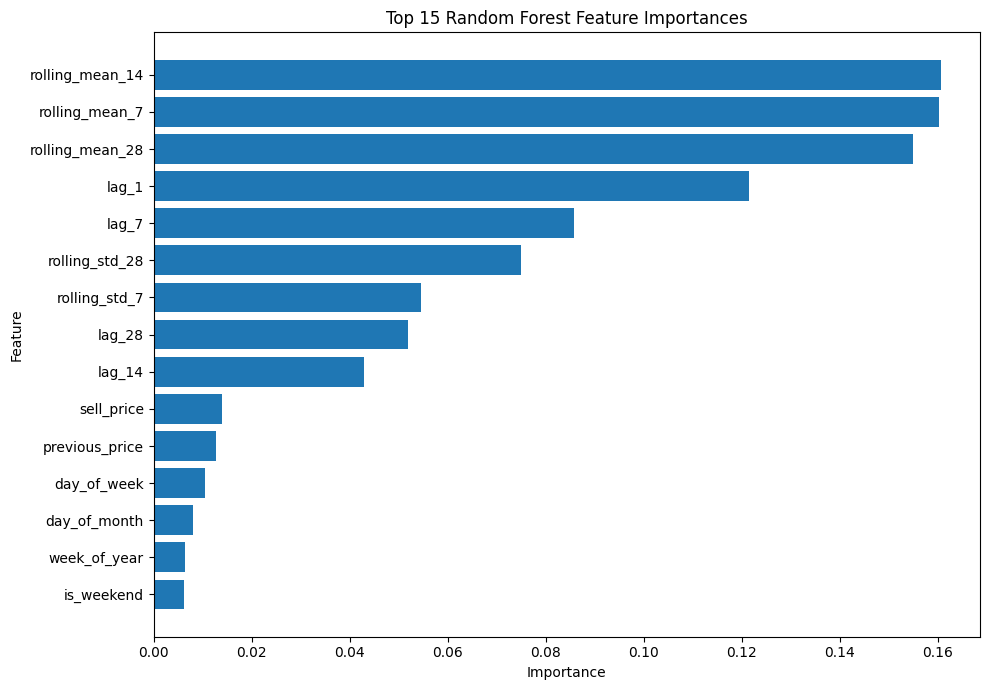

In [ ]:
# Plot the top 15 Random Forest features

top_rf_features = (
    rf_feature_importance
    .head(15)
    .sort_values(
        "Importance"
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_rf_features["Feature"],
    top_rf_features["Importance"]
)

plt.title(
    "Top 15 Random Forest Feature Importances"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
# Create Random Forest actual versus predicted dataset

rf_comparison = pd.DataFrame({
    "Actual_Sales": y_test_rf.values,
    "Predicted_Sales": rf_predictions
})

display(
    rf_comparison.head(20)
)

,Actual_Sales,Predicted_Sales
0,1,0.938712
1,0,1.382454
2,0,0.784677
3,1,0.298859
4,0,0.136500
5,0,0.452228
6,0,0.501400
7,0,0.435052
8,0,0.490579
9,0,0.281109


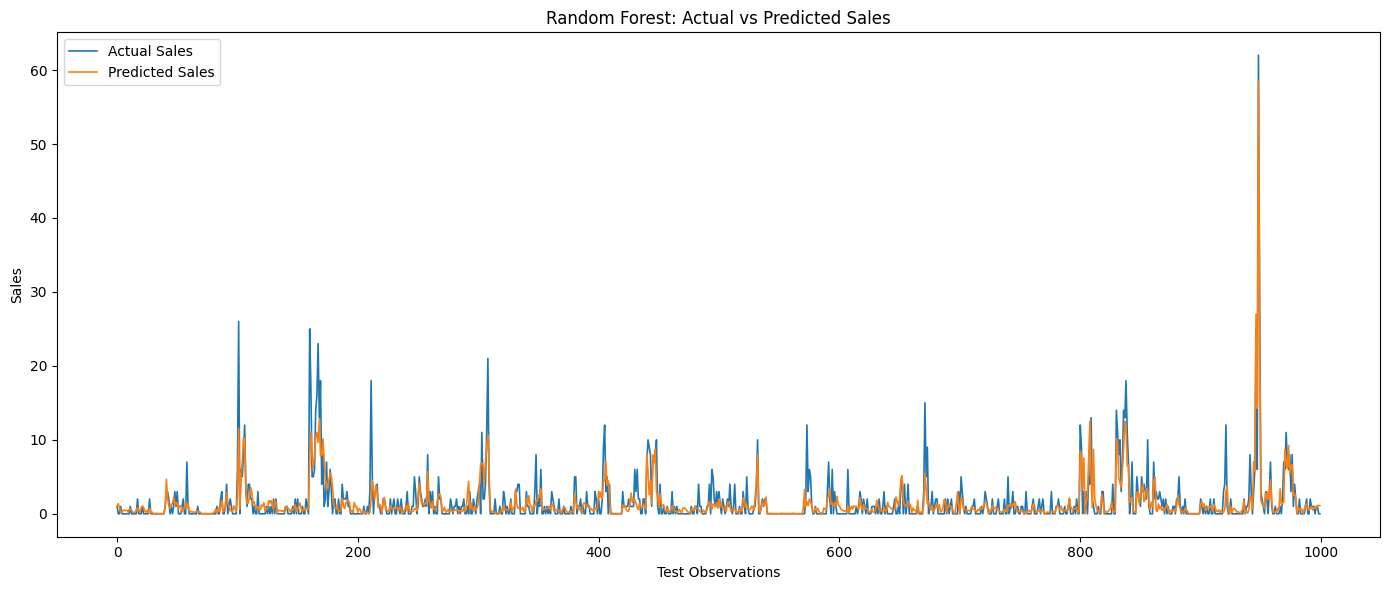

In [ ]:
# Plot actual versus predicted sales for Random Forest

plot_sample_size = min(
    1000,
    len(rf_comparison)
)

plot_data = (
    rf_comparison
    .iloc[:plot_sample_size]
    .copy()
)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["Actual_Sales"].values,
    label="Actual Sales",
    linewidth=1.2
)

plt.plot(
    plot_data["Predicted_Sales"].values,
    label="Predicted Sales",
    linewidth=1.2
)

plt.title(
    "Random Forest: Actual vs Predicted Sales"
)

plt.xlabel("Test Observations")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save the trained Random Forest model

joblib.dump(
    random_forest_model,
    "/random_forest_model.pkl"
)

print("Random Forest model saved .")

Random Forest model saved .


# Model 3: Gradient Boosting Regression

In [ ]:
# Prepare training and testing data for Gradient Boosting

X_train_gb = X_train_final.copy()
X_test_gb = X_test_final.copy()

y_train_gb = y_train_final.copy()
y_test_gb = y_test_final.copy()

print("Gradient Boosting data prepared.")
print("X_train shape:", X_train_gb.shape)
print("X_test shape:", X_test_gb.shape)

Gradient Boosting data prepared.
X_train shape: (3779290, 49)
X_test shape: (945190, 49)


In [ ]:
# Define the Histogram-based Gradient Boosting regression model
from sklearn.ensemble import HistGradientBoostingRegressor

gradient_boosting_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.08,
    max_leaf_nodes=31,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42
)

print("Gradient Boosting model defined.")

Gradient Boosting model defined.


In [ ]:
# Train the Gradient Boosting model

gradient_boosting_model.fit(
    X_train_gb,
    y_train_gb
)
print("Gradient Boosting model trained")
gb_predictions = (
    gradient_boosting_model.predict(
        X_test_gb
    )
)
print("Gradient boosting prediction generated")

Gradient Boosting model trained
Gradient boosting prediction generated


In [ ]:
# Ensure predicted demand cannot be negative

gb_predictions = np.maximum(gb_predictions,0)

print("Minimum Gradient Boosting prediction:",gb_predictions.min())

Minimum Gradient Boosting prediction: 0.0


In [ ]:
# Evaluate Gradient Boosting performance

gb_metrics = calculate_forecasting_metrics(
    y_test_gb,
    gb_predictions
)

print("Gradient Boosting Performance")
print("-----------------------------")
print(f"MAE  : {gb_metrics['MAE']:.4f}")
print(f"RMSE : {gb_metrics['RMSE']:.4f}")
print(f"R²   : {gb_metrics['R2']:.4f}")
print(f"MAPE : {gb_metrics['MAPE']:.2f}%")

Gradient Boosting Performance
-----------------------------
MAE  : 0.9998
RMSE : 1.9834
R²   : 0.7052
MAPE : 55.50%


In [ ]:
# Rebuild the model comparison table from the final model metrics

results = [
    {
        "Model": "Linear Regression",
        "MAE": lr_metrics["MAE"],
        "RMSE": lr_metrics["RMSE"],
        "R2": lr_metrics["R2"],
        "MAPE": lr_metrics["MAPE"]
    },
    {
        "Model": "Random Forest",
        "MAE": rf_metrics["MAE"],
        "RMSE": rf_metrics["RMSE"],
        "R2": rf_metrics["R2"],
        "MAPE": rf_metrics["MAPE"]
    },
    {
        "Model": "Gradient Boosting",
        "MAE": gb_metrics["MAE"],
        "RMSE": gb_metrics["RMSE"],
        "R2": gb_metrics["R2"],
        "MAPE": gb_metrics["MAPE"]
    }
]

results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(results_df)

,Model,MAE,RMSE,R2,MAPE
0,Random Forest,0.998559,1.947789,0.715727,55.094188
1,Gradient Boosting,0.999830,1.983423,0.705230,55.497796
2,Linear Regression,1.009945,2.015212,0.695706,58.099844


In [ ]:
# Create Gradient Boosting actual versus predicted dataset

gb_comparison = pd.DataFrame({
    "Actual_Sales": y_test_gb.values,
    "Predicted_Sales": gb_predictions
})

display(gb_comparison.head(20))

,Actual_Sales,Predicted_Sales
0,1,0.972939
1,0,1.675237
2,0,0.970173
3,1,0.282232
4,0,0.067481
5,0,0.441397
6,0,0.589840
7,0,0.426356
8,0,0.459901
9,0,0.195497


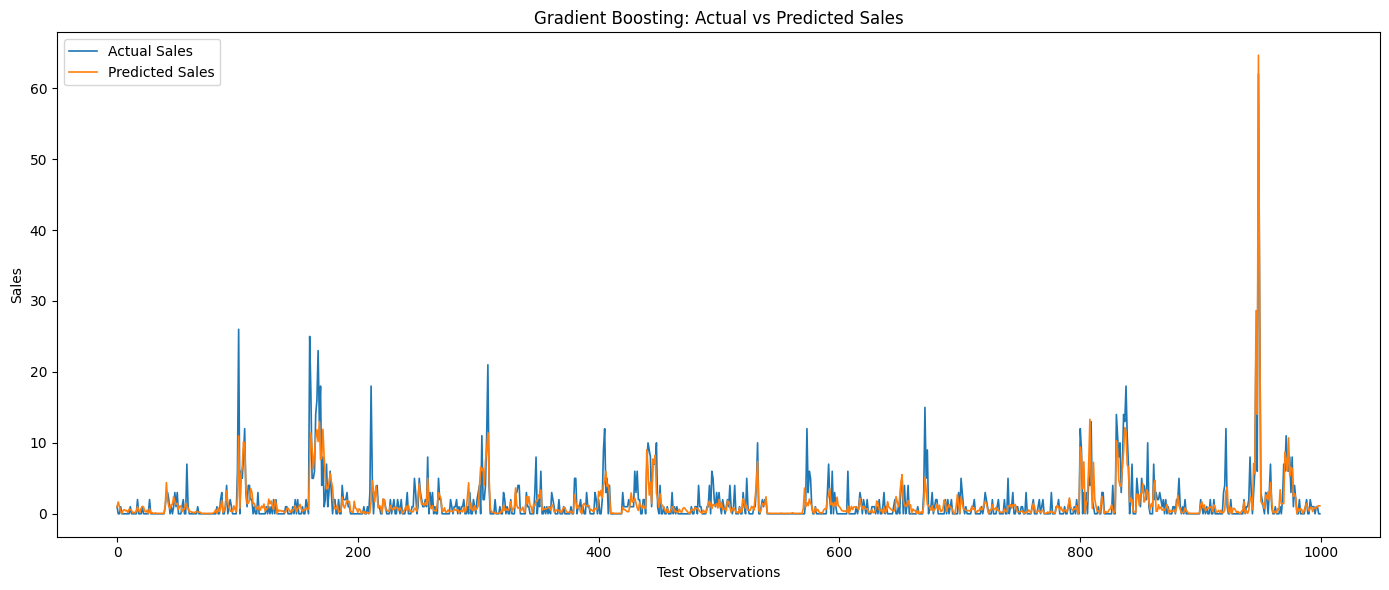

In [ ]:
# Plot actual versus predicted sales for Gradient Boosting

plot_sample_size = min(
    1000,
    len(gb_comparison)
)

plot_data = (
    gb_comparison
    .iloc[:plot_sample_size]
    .copy()
)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["Actual_Sales"].values,
    label="Actual Sales",
    linewidth=1.2
)

plt.plot(
    plot_data["Predicted_Sales"].values,
    label="Predicted Sales",
    linewidth=1.2
)

plt.title(
    "Gradient Boosting: Actual vs Predicted Sales"
)

plt.xlabel("Test Observations")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save the trained Gradient Boosting model

joblib.dump(
    gradient_boosting_model,
    "gradient_boosting_model.pkl"
)

print("Gradient Boosting model saved")

Gradient Boosting model saved


# 4. XG Boost Implementation

In [ ]:
# Prepare training and testing data for XGBoost

X_train_xgb = X_train_final.copy()
X_test_xgb = X_test_final.copy()

y_train_xgb = y_train_final.copy()
y_test_xgb = y_test_final.copy()

print("XGBoost data prepared.")
print("X_train shape:", X_train_xgb.shape)
print("X_test shape:", X_test_xgb.shape)

XGBoost data prepared.
X_train shape: (3779290, 49)
X_test shape: (945190, 49)


In [ ]:
# Define the XGBoost regression model

xgboost_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

print("XGBoost model defined.")

XGBoost model defined.


In [ ]:
# Training and make prediction for XGBoost

xgboost_model.fit(
    X_train_xgb,
    y_train_xgb
)
xgb_predictions = (
    xgboost_model.predict(
        X_test_xgb
    )
)
print("XG Boost Training and Make prediction generated")

XG Boost Training and Make prediction generated


In [ ]:
# Evaluate XGBoost performance

xgb_metrics = calculate_forecasting_metrics(
    y_test_xgb,
    xgb_predictions
)

print("XGBoost Performance")
print("-------------------")
print(f"MAE  : {xgb_metrics['MAE']:.4f}")
print(f"RMSE : {xgb_metrics['RMSE']:.4f}")
print(f"R²   : {xgb_metrics['R2']:.4f}")
print(f"MAPE : {xgb_metrics['MAPE']:.2f}%")

XGBoost Performance
-------------------
MAE  : 0.9966
RMSE : 1.9914
R²   : 0.7029
MAPE : 55.45%


In [ ]:
# Add XGBoost results to the model comparison

results.append({
    "Model": "XGBoost",
    "MAE": xgb_metrics["MAE"],
    "RMSE": xgb_metrics["RMSE"],
    "R2": xgb_metrics["R2"],
    "MAPE": xgb_metrics["MAPE"]
})

results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(results_df)

,Model,MAE,RMSE,R2,MAPE
0,Random Forest,0.998559,1.947789,0.715727,55.094188
1,Gradient Boosting,0.999830,1.983423,0.705230,55.497796
2,XGBoost,0.996621,1.991380,0.702861,55.453031
3,Linear Regression,1.009945,2.015212,0.695706,58.099844


In [ ]:
# Calculate XGBoost feature importance

xgb_feature_importance = pd.DataFrame({
    "Feature": X_train_xgb.columns,
    "Importance": xgboost_model.feature_importances_
})

xgb_feature_importance = (
    xgb_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    xgb_feature_importance.head(20)
)

,Feature,Importance
0,rolling_mean_7,0.352813
1,rolling_mean_14,0.232266
2,rolling_mean_28,0.093475
3,lag_1,0.030827
4,is_weekend,0.028987
5,lag_7,0.018115
6,year_num,0.016624
7,day_of_week,0.012553
8,lag_28,0.011201
9,lag_14,0.010594


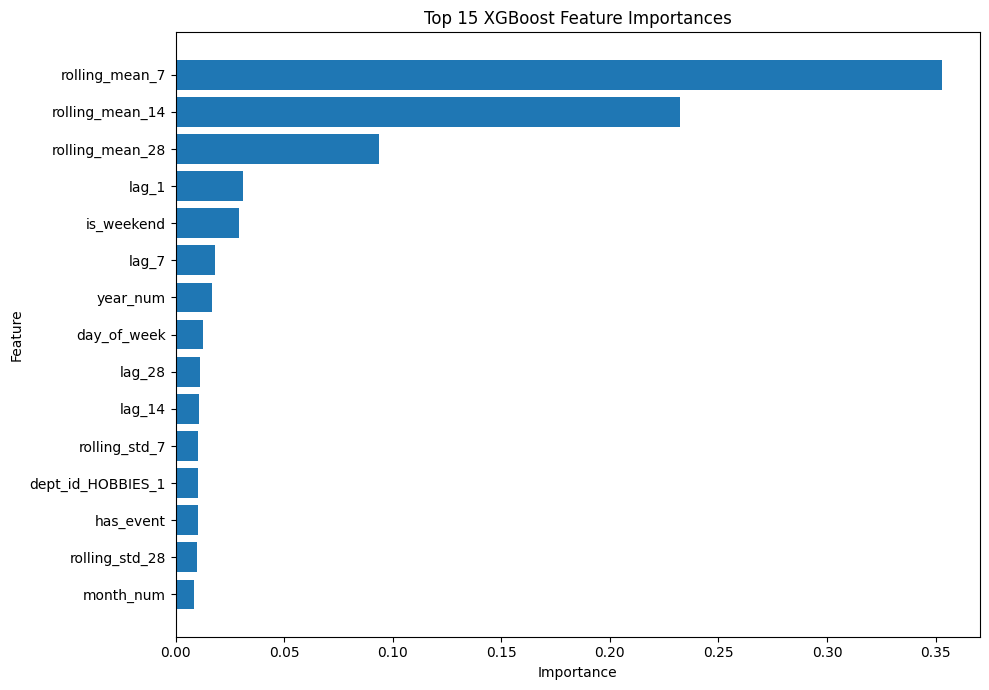

In [ ]:
# Plot the top 15 XGBoost features

top_xgb_features = (
    xgb_feature_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_xgb_features["Feature"],
    top_xgb_features["Importance"]
)

plt.title(
    "Top 15 XGBoost Feature Importances"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
# Create XGBoost actual versus predicted sales dataset

xgb_comparison = pd.DataFrame({
    "Actual_Sales": y_test_xgb.values,
    "Predicted_Sales": xgb_predictions
})

display(
    xgb_comparison.head(20)
)

,Actual_Sales,Predicted_Sales
0,1,0.987776
1,0,2.000886
2,0,0.759341
3,1,0.287807
4,0,0.119165
5,0,0.437121
6,0,0.557609
7,0,0.440810
8,0,0.451198
9,0,0.272924


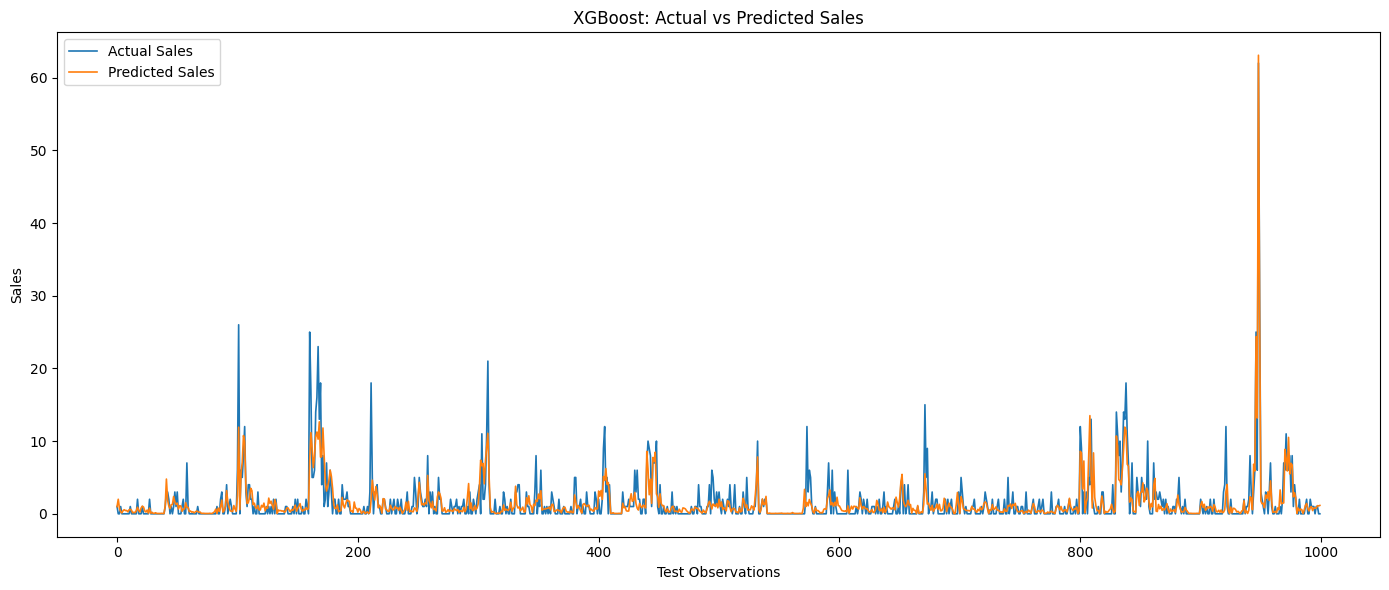

In [ ]:
# Plot actual versus predicted sales for XGBoost

plot_sample_size = min(
    1000,
    len(xgb_comparison)
)

plot_data = (
    xgb_comparison
    .iloc[:plot_sample_size]
    .copy()
)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["Actual_Sales"].values,
    label="Actual Sales",
    linewidth=1.2
)

plt.plot(
    plot_data["Predicted_Sales"].values,
    label="Predicted Sales",
    linewidth=1.2
)

plt.title(
    "XGBoost: Actual vs Predicted Sales"
)

plt.xlabel("Test Observations")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save the trained XGBoost model

joblib.dump(
    xgboost_model,
    "xgboost_model.pkl"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


# Model : 5 LSTM (Long Short Term Memory ) Implementation

In [ ]:
# Prepare the dataset for LSTM sequence modelling

lstm_features = ["sales", "sell_price", "day_of_week", "is_weekend", "has_event", "snap_active"]
lstm_df = (
    feature_df[
        ["id", "date"] + lstm_features
    ]
    .sort_values(
        ["id", "date"]
    )
    .reset_index(drop=True)
)

print("LSTM dataset shape:", lstm_df.shape)
print("Date range:", lstm_df["date"].min(), "to", lstm_df["date"].max())

LSTM dataset shape: (4724480, 8)
Date range: 2015-12-20 00:00:00 to 2016-05-22 00:00:00


In [ ]:
# Define the historical sequence length

SEQUENCE_LENGTH = 28

print(f"LSTM sequence length: {SEQUENCE_LENGTH} days")

LSTM sequence length: 28 days


In [ ]:
# Separate the chronological training and testing periods

lstm_train_df = (
    lstm_df[
        lstm_df["date"] <= train_end_date
    ]
    .copy()
)

lstm_test_df = (
    lstm_df[
        lstm_df["date"] >= test_start_date
    ]
    .copy()
)

print(
    "Training date range:",
    lstm_train_df["date"].min(),
    "to",
    lstm_train_df["date"].max()
)

print(
    "Testing date range:",
    lstm_test_df["date"].min(),
    "to",
    lstm_test_df["date"].max()
)

Training date range: 2015-12-20 00:00:00 to 2016-04-21 00:00:00
Testing date range: 2016-04-22 00:00:00 to 2016-05-22 00:00:00


In [ ]:
# Scale LSTM variables using training data only

lstm_scaler = StandardScaler()

lstm_train_scaled = lstm_train_df.copy()

lstm_train_scaled[lstm_features] = (
    lstm_scaler.fit_transform(
        lstm_train_df[lstm_features]
    )
)

print("LSTM scaler fitted using training data only.")

LSTM scaler fitted using training data only.


In [ ]:
# Apply the training-fitted scaler to the complete dataset

lstm_all_scaled = lstm_df.copy()

lstm_all_scaled[lstm_features] = (
    lstm_scaler.transform(
        lstm_df[lstm_features]
    )
)

print("Training-fitted scaling applied to all observations.")

Training-fitted scaling applied to all observations.


In [ ]:
# Create LSTM training sequences

def create_training_sequences(data, feature_columns, sequence_length, max_samples=200000):
    sequence_blocks = []
    target_blocks = []

    rng = np.random.default_rng(42)

    grouped_data = list(data.groupby("id", sort=False))

    selected_ids = rng.choice(
        len(grouped_data),
        size=min(
            len(grouped_data),
            max(
                1,
                max_samples // sequence_length
            )
        ),
        replace=False
    )

    remaining_samples = max_samples

    for group_index in selected_ids:

        _, group = grouped_data[group_index]

        group = (group.sort_values("date").reset_index(drop=True))

        values = group[
            feature_columns
        ].to_numpy(
            dtype=np.float32
        )

        dates = group["date"].to_numpy()

        valid_sequences = []

        for i in range(sequence_length, len(group)):

            sequence_dates = dates[i - sequence_length:i + 1]

            day_difference = (
                sequence_dates[-1] -
                sequence_dates[0]
            ).astype(
                "timedelta64[D]"
            ).astype(int)

            if day_difference != sequence_length:
                continue

            valid_sequences.append(i)

        if not valid_sequences:
            continue

        if len(valid_sequences) > remaining_samples:
            valid_sequences = valid_sequences[:remaining_samples]

        for i in valid_sequences:

            sequence_blocks.append(
                values[
                    i - sequence_length:i
                ]
            )

            target_blocks.append(values[i, 0])

        remaining_samples -= len(valid_sequences)

        if remaining_samples <= 0:
            break

    return (
        np.asarray(sequence_blocks, dtype=np.float32),
        np.asarray(target_blocks, dtype=np.float32)
    )


X_lstm_train, y_lstm_train = (
    create_training_sequences(
        lstm_train_scaled,
        lstm_features,
        SEQUENCE_LENGTH,
        max_samples=200000
    )
)

print("Training sequence shape:", X_lstm_train.shape)

print("Training target shape:", y_lstm_train.shape)

Training sequence shape: (200000, 28, 6)
Training target shape: (200000,)


In [ ]:
def create_test_sequences(
    data,
    feature_columns,
    sequence_length,
    test_start_date
):
    sequence_blocks = []
    target_blocks = []
    id_blocks = []
    date_blocks = []

    for series_id, group in data.groupby(
        "id",
        sort=False
    ):

        group = (
            group
            .sort_values("date")
            .reset_index(drop=True)
        )

        values = group[
            feature_columns
        ].to_numpy(
            dtype=np.float32
        )

        dates = group[
            "date"
        ].to_numpy()

        for i in range(
            sequence_length,
            len(group)
        ):

            target_date = dates[i]

            if target_date < np.datetime64(
                test_start_date
            ):
                continue

            sequence_dates = dates[
                i - sequence_length:i + 1
            ]

            day_difference = (
                sequence_dates[-1] -
                sequence_dates[0]
            ).astype(
                "timedelta64[D]"
            ).astype(int)

            if day_difference != sequence_length:
                continue

            sequence_blocks.append(
                values[
                    i - sequence_length:i
                ]
            )

            target_blocks.append(
                values[i, 0]
            )

            id_blocks.append(
                series_id
            )

            date_blocks.append(
                target_date
            )

    return (
        np.asarray(
            sequence_blocks,
            dtype=np.float32
        ),
        np.asarray(
            target_blocks,
            dtype=np.float32
        ),
        np.asarray(id_blocks),
        np.asarray(date_blocks)
    )


(
    X_lstm_test,
    y_lstm_test,
    lstm_test_ids,
    lstm_test_dates
) = create_test_sequences(
    lstm_all_scaled,
    lstm_features,
    SEQUENCE_LENGTH,
    test_start_date
)

print(
    "Test sequence shape:",
    X_lstm_test.shape
)

print(
    "Test target shape:",
    y_lstm_test.shape
)

print(
    "Test prediction observations:",
    f"{len(y_lstm_test):,}"
)

Test sequence shape: (945190, 28, 6)
Test target shape: (945190,)
Test prediction observations: 945,190


In [ ]:
# Verify that test sequences begin at the correct forecasting period

print(
    "First test prediction date:",
    pd.to_datetime(
        lstm_test_dates.min()
    )
)

print(
    "Expected test start date:",
    test_start_date
)

if pd.to_datetime(
    lstm_test_dates.min()
) < test_start_date:
    raise ValueError(
        "Test sequences contain observations before the test period."
    )

print("Test sequence date validation completed.")

First test prediction date: 2016-04-22 00:00:00
Expected test start date: 2016-04-22 00:00:00
Test sequence date validation completed.


In [ ]:
# Build the LSTM neural network

lstm_model = Sequential([
    LSTM(32,
        input_shape=(
            SEQUENCE_LENGTH,
            len(lstm_features)
        )
    ),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")

lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,537 (21.63 KB)

 Trainable params: 5,537 (21.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Configure early stopping to reduce unnecessary training

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("Early stopping configured.")

Early stopping configured.


In [ ]:
# Train the LSTM model


lstm_history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_split=0.10,
    epochs=15,
    batch_size=512,
    callbacks=[early_stopping],
    verbose=1,
    shuffle=False
)


Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.5769 - val_loss: 0.4276
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.5241 - val_loss: 0.4018
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.5065 - val_loss: 0.4096
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.4861 - val_loss: 0.3964
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.4923 - val_loss: 0.3960
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.4880 - val_loss: 0.3904
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.4537 - val_loss: 0.3936
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.4427 - val_loss: 0.3860
Epoch 9/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.4371 - val_loss: 0.3843
Epoch 10/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.4412 - val_loss: 0.3822
Epoch 11/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.4263 - val_loss: 0.3857
Epoch 12/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Generate LSTM predictions

lstm_predictions_scaled = (
    lstm_model.predict(
        X_lstm_test,
        batch_size=512,
        verbose=1
    )
    .flatten()
)
print(
    "LSTM predictions generated."
)

1847/1847 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step
LSTM predictions generated.


In [ ]:
# Convert scaled predictions back to the original sales scale

sales_index = (lstm_features.index("sales"))

sales_mean = (lstm_scaler.mean_[sales_index])

sales_scale = (lstm_scaler.scale_[sales_index])

lstm_predictions = (
    lstm_predictions_scaled *
    sales_scale
    +
    sales_mean
)

# Sales cannot be negative
lstm_predictions = np.maximum(lstm_predictions, 0)

# Convert actual scaled sales back to original scale
lstm_actual_sales = (y_lstm_test * sales_scale + sales_mean)

print(
    "Minimum predicted sales:",
    lstm_predictions.min()
)

print(
    "Minimum actual sales:",
    lstm_actual_sales.min()
)

Minimum predicted sales: 0.0
Minimum actual sales: 4.3117178938345546e-08


In [ ]:
# Evaluate LSTM forecasting performance

lstm_metrics = calculate_forecasting_metrics(
    lstm_actual_sales,
    lstm_predictions
)

print("LSTM Performance")
print("----------------")
print(
    f"MAE  : {lstm_metrics['MAE']:.4f}"
)

print(
    f"RMSE : {lstm_metrics['RMSE']:.4f}"
)

print(
    f"R²   : {lstm_metrics['R2']:.4f}"
)

print(
    f"MAPE : {lstm_metrics['MAPE']:.2f}%"
)

LSTM Performance
----------------
MAE  : 1.0333
RMSE : 2.0140
R²   : 0.6961
MAPE : 797289037.56%


In [ ]:
# Create actual versus predicted LSTM results

lstm_comparison = pd.DataFrame({
    "id": lstm_test_ids,
    "date": pd.to_datetime(
        lstm_test_dates
    ),
    "Actual_Sales": lstm_actual_sales,
    "Predicted_Sales": lstm_predictions
})

display(
    lstm_comparison.head()
)

,id,date,Actual_Sales,Predicted_Sales
0,FOODS_1_001_CA_1_evaluation,2016-04-22,1.000000e+00,1.060662
1,FOODS_1_001_CA_1_evaluation,2016-04-23,1.000000e+00,1.214162
2,FOODS_1_001_CA_1_evaluation,2016-04-24,4.311718e-08,1.219439
3,FOODS_1_001_CA_1_evaluation,2016-04-25,2.000000e+00,1.025650
4,FOODS_1_001_CA_1_evaluation,2016-04-26,4.311718e-08,0.959515


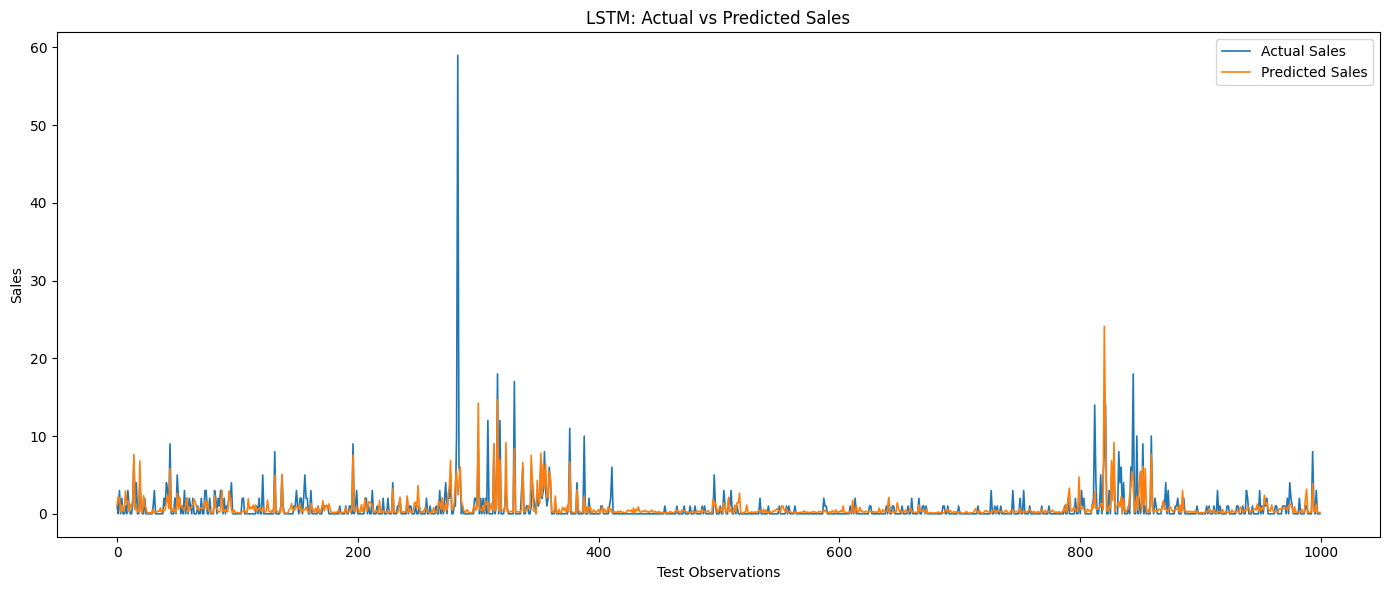

In [ ]:
# Plot actual versus predicted LSTM sales

plot_sample_size = min(
    1000,
    len(lstm_comparison)
)

plot_data = (
    lstm_comparison
    .sort_values("date")
    .head(plot_sample_size)
)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["Actual_Sales"].values,
    label="Actual Sales",
    linewidth=1.2
)

plt.plot(
    plot_data["Predicted_Sales"].values,
    label="Predicted Sales",
    linewidth=1.2
)

plt.title(
    "LSTM: Actual vs Predicted Sales"
)

plt.xlabel("Test Observations")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save the trained LSTM model and scaler

lstm_model.save(
    "lstm_model.keras"
)

joblib.dump(
    lstm_scaler,
    "lstm_scaler.pkl"
)

print(
    "LSTM model and scaler saved successfully."
)

LSTM model and scaler saved successfully.


In [ ]:
# Calculate LSTM MAPE using actual positive sales observations only

lstm_actual_array = np.asarray(
    lstm_actual_sales
)

lstm_prediction_array = np.asarray(
    lstm_predictions
)

# Sales are integer units, so values below 1 are treated as zero
positive_sales_mask = (
    lstm_actual_array >= 1
)

lstm_mape = (
    np.mean(
        np.abs(
            (
                lstm_actual_array[
                    positive_sales_mask
                ]
                -
                lstm_prediction_array[
                    positive_sales_mask
                ]
            )
            /
            lstm_actual_array[
                positive_sales_mask
            ]
        )
    )
    * 100
)

print(
    f"Corrected LSTM MAPE: {lstm_mape:.4f}%"
)

Corrected LSTM MAPE: 57.6726%


In [ ]:
# Update the LSTM result with the corrected MAPE

lstm_metrics["MAPE"] = lstm_mape

results = [
    {
        "Model": "Linear Regression",
        "MAE": lr_metrics["MAE"],
        "RMSE": lr_metrics["RMSE"],
        "R2": lr_metrics["R2"],
        "MAPE": lr_metrics["MAPE"]
    },
    {
        "Model": "Random Forest",
        "MAE": rf_metrics["MAE"],
        "RMSE": rf_metrics["RMSE"],
        "R2": rf_metrics["R2"],
        "MAPE": rf_metrics["MAPE"]
    },
    {
        "Model": "Gradient Boosting",
        "MAE": gb_metrics["MAE"],
        "RMSE": gb_metrics["RMSE"],
        "R2": gb_metrics["R2"],
        "MAPE": gb_metrics["MAPE"]
    },
    {
        "Model": "XGBoost",
        "MAE": xgb_metrics["MAE"],
        "RMSE": xgb_metrics["RMSE"],
        "R2": xgb_metrics["R2"],
        "MAPE": xgb_metrics["MAPE"]
    },
    {
        "Model": "LSTM",
        "MAE": lstm_metrics["MAE"],
        "RMSE": lstm_metrics["RMSE"],
        "R2": lstm_metrics["R2"],
        "MAPE": lstm_metrics["MAPE"]
    }
]

results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(results_df)

,Model,MAE,RMSE,R2,MAPE
0,Random Forest,0.998559,1.947789,0.715727,55.094188
1,Gradient Boosting,0.999830,1.983423,0.705230,55.497796
2,XGBoost,0.996621,1.991380,0.702861,55.453031
3,LSTM,1.033265,2.013962,0.696083,57.672562
4,Linear Regression,1.009945,2.015212,0.695706,58.099844


In [ ]:
# Create combined model comparison including tuned Random Forest

comparison_df = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": lr_metrics["MAE"],
        "RMSE": lr_metrics["RMSE"],
        "R2": lr_metrics["R2"],
        "MAPE": lr_metrics["MAPE"]
    },
    {
        "Model": "Original Random Forest",
        "MAE": rf_metrics["MAE"],
        "RMSE": rf_metrics["RMSE"],
        "R2": rf_metrics["R2"],
        "MAPE": rf_metrics["MAPE"]
    },
    {
        "Model": "Gradient Boosting",
        "MAE": gb_metrics["MAE"],
        "RMSE": gb_metrics["RMSE"],
        "R2": gb_metrics["R2"],
        "MAPE": gb_metrics["MAPE"]
    },
    {
        "Model": "XGBoost",
        "MAE": xgb_metrics["MAE"],
        "RMSE": xgb_metrics["RMSE"],
        "R2": xgb_metrics["R2"],
        "MAPE": xgb_metrics["MAPE"]
    },
    {
        "Model": "LSTM",
        "MAE": lstm_metrics["MAE"],
        "RMSE": lstm_metrics["RMSE"],
        "R2": lstm_metrics["R2"],
        "MAPE": lstm_metrics["MAPE"]
    }
])

display(comparison_df)

,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,1.009945,2.015212,0.695706,58.099844
1,Original Random Forest,0.998559,1.947789,0.715727,55.094188
2,Gradient Boosting,0.999830,1.983423,0.705230,55.497796
3,XGBoost,0.996621,1.991380,0.702861,55.453031
4,LSTM,1.033265,2.013962,0.696083,57.672562


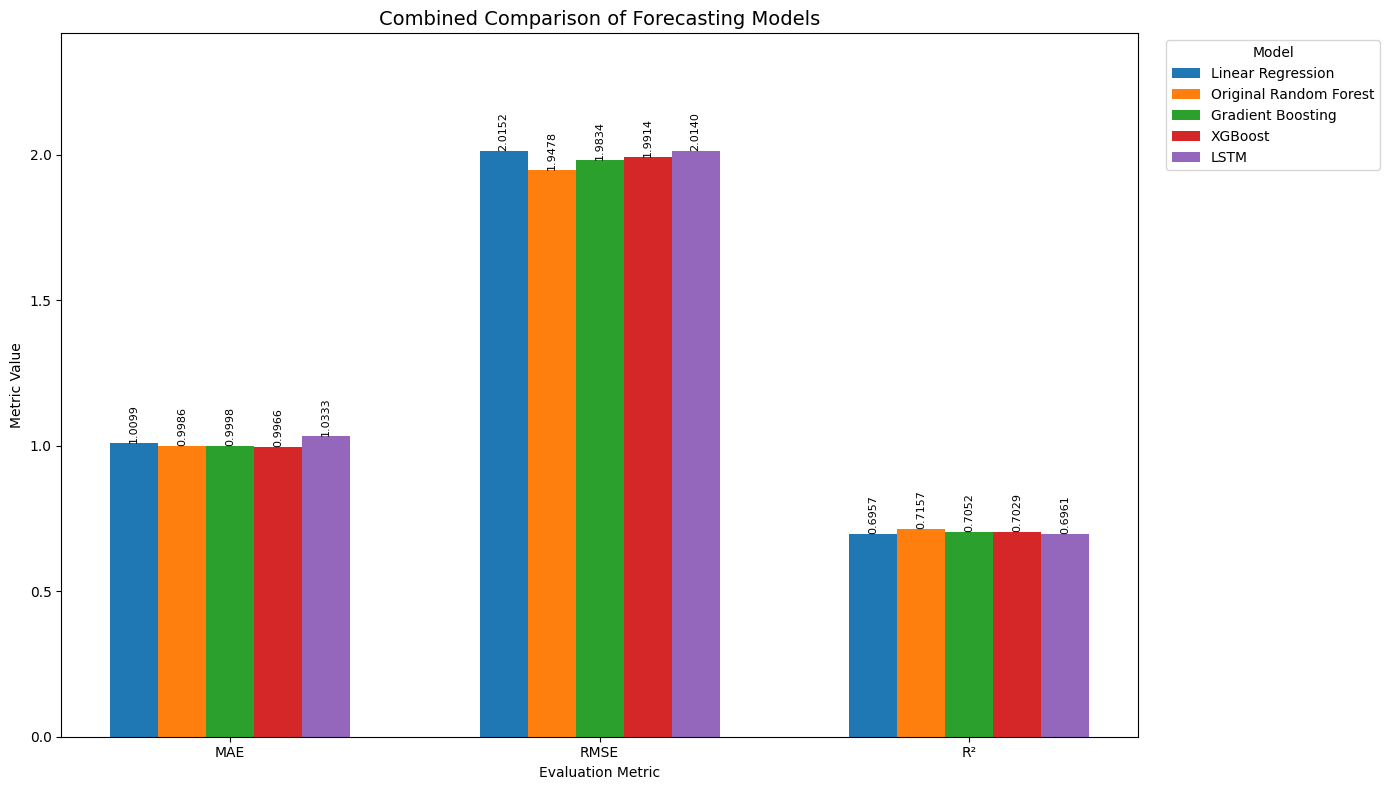

In [ ]:
# Create combined model comparison without MAPE

metrics = [
    "MAE",
    "RMSE",
    "R2"
]

model_names = comparison_df["Model"].tolist()

x = np.arange(len(metrics))

width = 0.13

fig, ax = plt.subplots(
    figsize=(14, 8)
)

# Create grouped bars for each model
for i, model in enumerate(model_names):

    model_values = [
        comparison_df.loc[
            comparison_df["Model"] == model,
            metric
        ].iloc[0]
        for metric in metrics
    ]

    bars = ax.bar(
        x + (i - (len(model_names) - 1) / 2) * width,
        model_values,
        width,
        label=model
    )

    # Add value labels above each bar
    for bar, value in zip(
        bars,
        model_values
    ):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

ax.set_title(
    "Combined Comparison of Forecasting Models",
    fontsize=14
)

ax.set_xlabel(
    "Evaluation Metric"
)

ax.set_ylabel(
    "Metric Value"
)

ax.set_xticks(x)

ax.set_xticklabels(
    [
        "MAE",
        "RMSE",
        "R²"
    ]
)

# Provide space for value labels
ax.set_ylim(
    0,
    max(
        comparison_df[metrics].max()
    ) * 1.20
)

ax.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

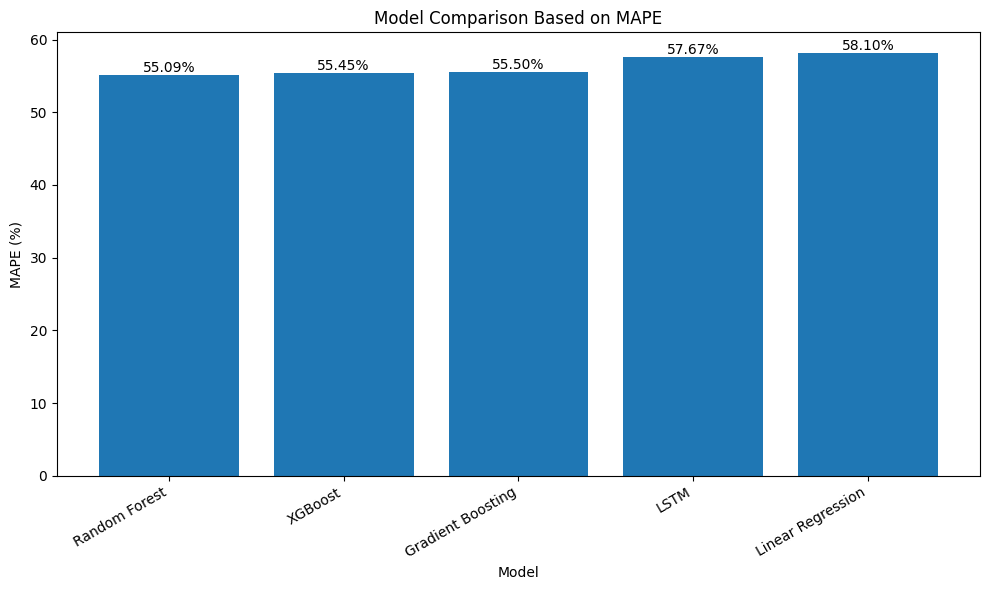

In [ ]:
# Plot MAPE comparison across forecasting models with value labels

mape_plot = (
    results_df
    .sort_values("MAPE")
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    mape_plot["Model"],
    mape_plot["MAPE"]
)

plt.title("Model Comparison Based on MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")

plt.xticks(
    rotation=30,
    ha="right"
)

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()